# FER2013 Import


In [ ]:
# First: remove broken conflicting versions
!pip uninstall -y tensorflow tensorflow-text tf-keras tensorflow-decision-forests

# Install only compatible versions (Colab works best with TF 2.19.0)
!pip install tensorflow==2.19.0 tensorflow-text==2.19.0 tf-keras==2.19.0 tensorflow-decision-forests==1.12.0 --quiet


Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: tensorflow-text 2.19.0
Uninstalling tensorflow-text-2.19.0:
  Successfully uninstalled tensorflow-text-2.19.0
Found existing installation: tf_keras 2.19.0
Uninstalling tf_keras-2.19.0:
  Successfully uninstalled tf_keras-2.19.0
Found existing installation: tensorflow_decision_forests 1.12.0
Uninstalling tensorflow_decision_forests-1.12.0:
  Successfully uninstalled tensorflow_decision_forests-1.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 10.3 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled")
    except RuntimeError as e:
        print(e)


✅ GPU memory growth enabled


In [ ]:
!pip install kaggle -q
!mkdir -p ~/.kaggle
!echo '{"username":"YOUR_KAGGLE_USERNAME","key":"YOUR_API_KEY"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d msambare/fer2013 -p /content/datasets
!unzip -qo /content/datasets/fer2013.zip -d /content/datasets

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 1.74GB/s]


In [ ]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/datasets"))

['.config', 'datasets', 'sample_data']
['test', 'train', 'fer2013.zip']


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for f in files:
        if "fer" in f.lower():
            print(os.path.join(root, f))


/content/datasets/fer2013.zip


In [ ]:
!sudo apt-get install cmake
!pip install dlib


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
pip install mtcnn opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.3 MB/s eta 0:00:00


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Loading training data...
Loaded 28709 images from /content/datasets/train
Loading test data...
Loaded 7178 images from /content/datasets/test


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 24,    │     18,496 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 24, 24,    │      8,896 │ re_lu_1[0][0]     │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 12, 12,    │     17,664 │ re_lu_2[0][0]     │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │      8,320 │ re_lu_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 12,    │          0 │ conv2d_2[0][0],   │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 12, 12,    │          0 │ add[0][0]         │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 12, 12,    │     34,176 │ re_lu_3[0][0]     │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │      1,024 │ separable_conv2d

 Total params: 1,378,247 (5.26 MB)

 Trainable params: 1,375,495 (5.25 MB)

...

449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6602 - loss: 0.9173 - val_accuracy: 0.6193 - val_loss: 1.0134 - learning_rate: 2.5000e-04
Epoch 24/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6549 - loss: 0.9239
Epoch 24: val_loss did not improve from 1.01340
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6549 - loss: 0.9239 - val_accuracy: 0.6211 - val_loss: 1.0326 - learning_rate: 2.5000e-04
Epoch 25/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6666 - loss: 0.9005
Epoch 25: val_loss improved from 1.01340 to 0.99380, saving model to best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.6666 - loss: 0.9005 - val_accuracy: 0.6297 - val_loss: 0.9938 - learning_rate: 2.5000e-04
Epoch 26/40
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6597 - loss: 0.9114
Epoch 26: val_loss did not improve from 0.99380
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6597 - loss: 0.9114 - val_accuracy: 0.6367 - val_loss: 0.9962 - learning_rate: 2.5000e-04
Epoch 27/40
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6663 - loss: 0.8921
Epoch 27: val_loss did not improve from 0.99380
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6663 - loss: 0.8922 - val_accuracy: 0.6287 - val_loss: 1.0153 - learning_rate: 2.5000e-04
Epoch 28/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6667 - loss: 0.8921
Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 28: val_loss did not improve from 0.99380
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.6666 - loss: 0.8

449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6735 - loss: 0.8814 - val_accuracy: 0.6463 - val_loss: 0.9743 - learning_rate: 1.2500e-04
Epoch 31/40
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6691 - loss: 0.8771
Epoch 31: val_loss did not improve from 0.97433
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.6691 - loss: 0.8770 - val_accuracy: 0.6315 - val_loss: 1.0085 - learning_rate: 1.2500e-04
Epoch 32/40
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6743 - loss: 0.8748
Epoch 32: val_loss did not improve from 0.97433
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.6743 - loss: 0.8748 - val_accuracy: 0.6408 - val_loss: 0.9827 - learning_rate: 1.2500e-04
Epoch 33/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6726 - loss: 0.8638
Epoch 33: val_loss improved from 0.97433 to 0.97159, saving model to best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6726 - loss: 0.8638 - val_accuracy: 0.6516 - val_loss: 0.9716 - learning_rate: 1.2500e-04
Epoch 34/40
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6788 - loss: 0.8615
Epoch 34: val_loss improved from 0.97159 to 0.97115, saving model to best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.6788 - loss: 0.8615 - val_accuracy: 0.6457 - val_loss: 0.9711 - learning_rate: 1.2500e-04
Epoch 35/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6858 - loss: 0.8529
Epoch 35: val_loss did not improve from 0.97115
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6858 - loss: 0.8529 - val_accuracy: 0.6456 - val_loss: 0.9899 - learning_rate: 1.2500e-04
Epoch 36/40
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6794 - loss: 0.8546
Epoch 36: val_loss did not improve from 0.97115
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6793 - loss: 0.8547 - val_accuracy: 0.6350 - val_loss: 1.0018 - learning_rate: 1.2500e-04
Epoch 37/40
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6798 - loss: 0.8610
Epoch 37: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 37: val_loss did not improve from 0.97115
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6797 - loss: 0.86

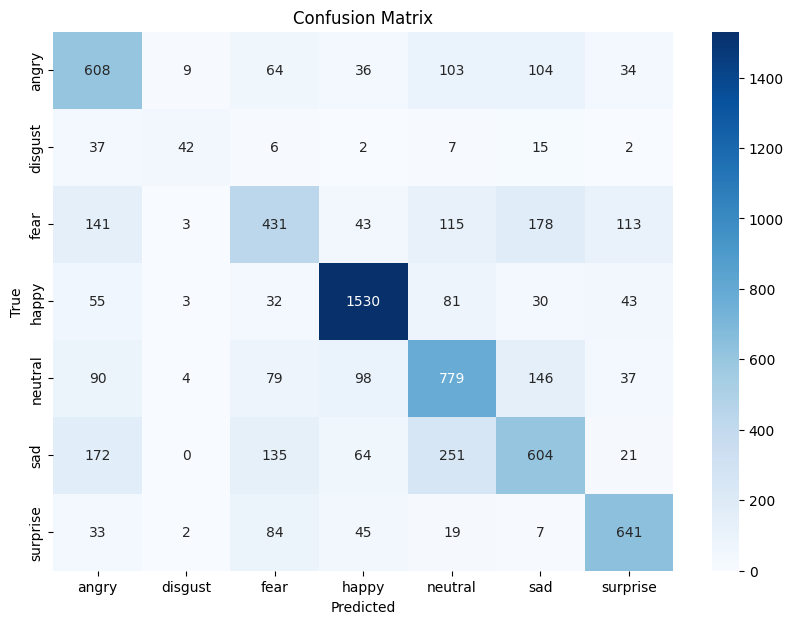

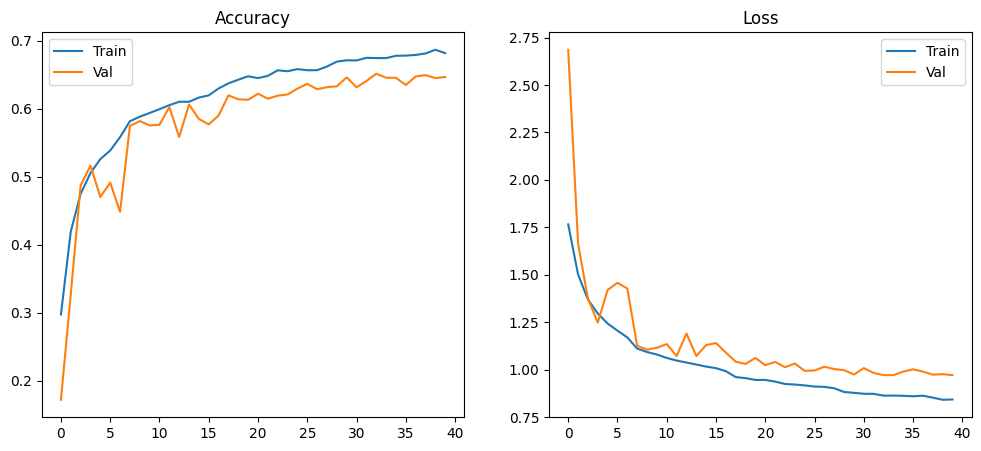

In [ ]:
"""
FER-2013 Emotion Recognition
Dlib 68-Landmark Face Alignment + Mini-Xception CNN

Expected Accuracy:
 - 68–76% validation accuracy
 - Best epoch around 15–22
"""

# ===========================================
# 1. IMPORTS
# ===========================================
import os
import numpy as np
import cv2
import dlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Seed
np.random.seed(42)
tf.random.set_seed(42)

# ===========================================
# 2. PATHS & SETTINGS
# ===========================================
train_dir = "/content/datasets/train"
test_dir  = "/content/datasets/test"

img_size = (48, 48)
num_classes = 7
batch_size = 64
epochs = 40  # early stopping will end earlier

classes = sorted(os.listdir(train_dir))
print("Classes:", classes)

# ===========================================
# 3. DLIB FACE DETECTOR + LANDMARK PREDICTOR
# ===========================================

# Download shape predictor if needed
if not os.path.exists("shape_predictor_68_face_landmarks.dat"):
    !wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
    !bzip2 -dk shape_predictor_68_face_landmarks.dat.bz2

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# ===========================================
# 4. ALIGNMENT FUNCTION (HIGHLY STABLE)
# ===========================================

def align_face_dlib(img, output_size=(48,48), expand_ratio=0.30):
    """
    Face alignment using:
      - Dlib HOG detector
      - 68 landmarks
      - Eye-alignment rotation + expanded crop
    """
    if img is None:
        return np.zeros(output_size, np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rects = detector(gray)

    if len(rects) == 0:
        # fallback to plain resize
        return cv2.resize(gray, output_size)

    rect = rects[0]
    shape = predictor(gray, rect)
    shape_np = np.array([[p.x, p.y] for p in shape.parts()])

    # Get eye centers
    left_eye  = shape_np[36:42].mean(axis=0).astype("int")
    right_eye = shape_np[42:48].mean(axis=0).astype("int")

    # Compute rotation angle
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))

    # Rotate around eye midpoint
    eye_center = tuple(((left_eye + right_eye) // 2))
    rot_mat = cv2.getRotationMatrix2D(eye_center, angle, 1.0)
    rotated = cv2.warpAffine(gray, rot_mat, (gray.shape[1], gray.shape[0]),
                             flags=cv2.INTER_CUBIC)

    # Expanded bounding box
    x, y, w, h = rect.left(), rect.top(), rect.width(), rect.height()
    x = max(0, int(x - w * expand_ratio))
    y = max(0, int(y - h * expand_ratio))
    w = int(w * (1 + 2*expand_ratio))
    h = int(h * (1 + 2*expand_ratio))

    crop = rotated[y:y+h, x:x+w]
    if crop.size == 0:
        return cv2.resize(gray, output_size)

    aligned = cv2.resize(crop, output_size)
    return aligned

# ===========================================
# 5. LOAD DATASET
# ===========================================

def load_dataset(folder):
    X, y = [], []
    class_map = {cls:i for i, cls in enumerate(classes)}

    for cls in classes:
        folder_cls = os.path.join(folder, cls)
        for file in os.listdir(folder_cls):
            img_path = os.path.join(folder_cls, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            aligned = align_face_dlib(img)
            X.append(aligned)
            y.append(class_map[cls])

    X = np.array(X).reshape(-1, 48, 48, 1) / 255.0
    y = tf.keras.utils.to_categorical(y, num_classes)
    print(f"Loaded {X.shape[0]} images from {folder}")
    return X, y


print("\nLoading training data...")
X_train, y_train = load_dataset(train_dir)

print("Loading test data...")
X_test, y_test = load_dataset(test_dir)

# ===========================================
# 6. DATA AUGMENTATION
# ===========================================
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=5,
    horizontal_flip=True
)
datagen.fit(X_train)

# ===========================================
# 7. MINI-XCEPTION MODEL (BEST FOR FER)
# ===========================================
def mini_xception(input_shape=(48,48,1), n_classes=7):

    inp = Input(input_shape)

    # Entry
    x = Conv2D(32, (3,3), padding='same')(inp)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(64, (3,3), strides=2, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    def res_block(x, filters):
        res = Conv2D(filters, (1,1), strides=2, padding='same')(x)

        y = SeparableConv2D(filters, (3,3), padding='same')(x)
        y = BatchNormalization()(y)
        y = ReLU()(y)

        y = SeparableConv2D(filters, (3,3), strides=2, padding='same')(y)
        y = BatchNormalization()(y)

        out = Add()([res, y])
        out = ReLU()(out)
        return out

    x = res_block(x, 128)
    x = res_block(x, 256)

    x = Conv2D(512, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    out = Dense(n_classes, activation="softmax")(x)
    model = Model(inp, out)
    return model


model = mini_xception()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ===========================================
# 8. TRAINING SETUP
# ===========================================
callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_loss", verbose=1),
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size),
    validation_data=(X_test, y_test),
    epochs=epochs,
    callbacks=callbacks
)

# ===========================================
# 9. EVALUATION
# ===========================================
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Accuracy curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["Train","Val"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["Train","Val"])
plt.show()


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Loading full training set...
Loaded 28709 images from /content/datasets/train
Loading test set (kept untouched)...
Loaded 7178 images from /content/datasets/test

Split: train=25263  val=3446  test=7178
Class weights: {0: 1.0264505119453924, 1: 9.3984375, 2: 1.0011095700416088, 3: 0.5684359741691605, 4: 0.8260471503776607, 5: 0.8491764705882353, 6: 1.293548387096774}

Training with optimizer: sgd
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.1595 - loss: 2.2505
Epoch 1: val_accuracy improved from -inf to 0.14539, saving model to best_sgd.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 45s 88ms/step - accuracy: 0.1595 - loss: 2.2503 - val_accuracy: 0.1454 - val_loss: 2.1343 - learning_rate: 0.0300
Epoch 2/40
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2211 - loss: 2.1246
Epoch 2: val_accuracy improved from 0.14539 to 0.25189, saving model to best_sgd.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.2211 - loss: 2.1245 - val_accuracy: 0.2519 - val_loss: 2.1390 - learning_rate: 0.0300
Epoch 3/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2851 - loss: 2.0293
Epoch 3: val_accuracy improved from 0.25189 to 0.30035, saving model to best_sgd.h5


...

395/395 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4391 - loss: 1.7490 - val_accuracy: 0.4672 - val_loss: 1.7141 - learning_rate: 0.0050
Epoch 12/40
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4361 - loss: 1.7639
Epoch 12: val_accuracy did not improve from 0.46721
395/395 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.4361 - loss: 1.7638 - val_accuracy: 0.4521 - val_loss: 1.7493 - learning_rate: 0.0050
Epoch 13/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4483 - loss: 1.7592
Epoch 13: val_accuracy improved from 0.46721 to 0.47766, saving model to best_adagrad.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.4483 - loss: 1.7592 - val_accuracy: 0.4777 - val_loss: 1.6854 - learning_rate: 0.0050
Epoch 14/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4524 - loss: 1.7311
Epoch 14: val_accuracy improved from 0.47766 to 0.49391, saving model to best_adagrad.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4524 - loss: 1.7311 - val_accuracy: 0.4939 - val_loss: 1.6655 - learning_rate: 0.0050
Epoch 15/40
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4575 - loss: 1.7365
Epoch 15: val_accuracy did not improve from 0.49391
395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4575 - loss: 1.7364 - val_accuracy: 0.3984 - val_loss: 1.8429 - learning_rate: 0.0050
Epoch 16/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4639 - loss: 1.7040
Epoch 16: val_accuracy did not improve from 0.49391
395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4639 - loss: 1.7041 - val_accuracy: 0.4663 - val_loss: 1.6937 - learning_rate: 0.0050
Epoch 17/40
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4563 - loss: 1.7260
Epoch 17: val_accuracy did not improve from 0.49391
395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4563 - loss: 1.7260 - val_accuracy: 0.4925 - val_loss: 1.6642 - learning_rate: 0.0050
Epoch 18

395/395 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.4703 - loss: 1.7027 - val_accuracy: 0.5096 - val_loss: 1.6472 - learning_rate: 0.0050
Epoch 20/40
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4695 - loss: 1.6882
Epoch 20: val_accuracy did not improve from 0.50958
395/395 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.4696 - loss: 1.6882 - val_accuracy: 0.4765 - val_loss: 1.7127 - learning_rate: 0.0050
Epoch 21/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4729 - loss: 1.6797
Epoch 21: val_accuracy improved from 0.50958 to 0.52089, saving model to best_adagrad.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.4729 - loss: 1.6797 - val_accuracy: 0.5209 - val_loss: 1.6193 - learning_rate: 0.0050
Epoch 22/40
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4802 - loss: 1.6573
Epoch 22: val_accuracy did not improve from 0.52089
395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4802 - loss: 1.6574 - val_accuracy: 0.5026 - val_loss: 1.6524 - learning_rate: 0.0050
Epoch 23/40
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4849 - loss: 1.6599
Epoch 23: val_accuracy did not improve from 0.52089
395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.4849 - loss: 1.6600 - val_accuracy: 0.4704 - val_loss: 1.7066 - learning_rate: 0.0050
Epoch 24/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4848 - loss: 1.6692
Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 24: val_accuracy did not improve from 0.52089
395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4848 - loss: 1.6

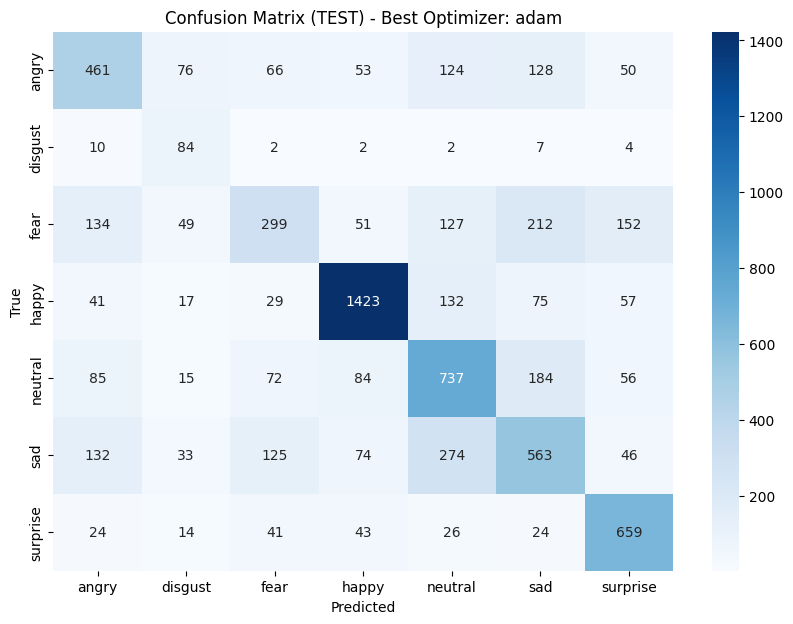

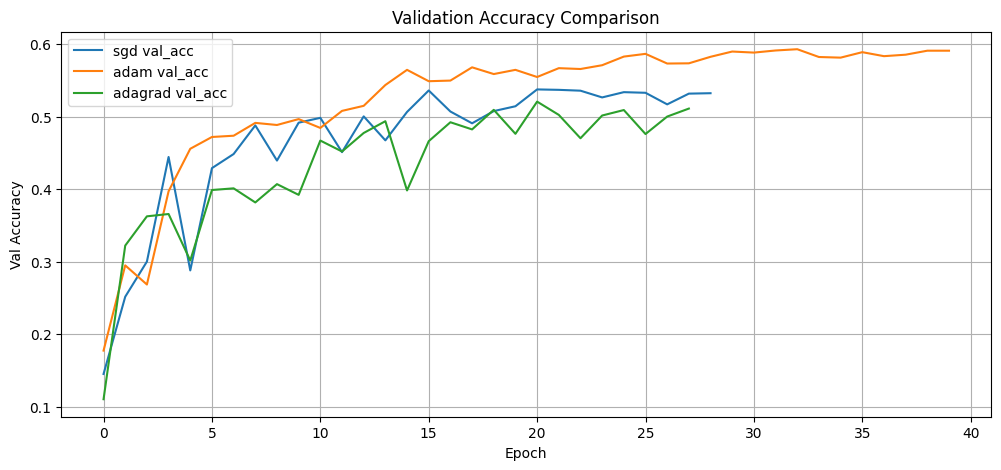


Saved final best model to: final_best_model.keras


In [ ]:
"""
FER-2013 Emotion Recognition
Dlib 68-Landmark Face Alignment + Mini-Xception CNN
Optimizer comparison: SGD(no momentum) vs Adam vs Adagrad

Edits included to push validation accuracy upward:
- Proper train/val split (test kept untouched -> honest test metrics)
- CLAHE + per-image standardization (better contrast / illumination robustness)
- Class weights (helps minority classes like disgust)
- Label smoothing (improves generalization)
- Slightly stronger Mini-Xception (extra residual block + L2 + dropout)

NOTE: Final accuracy depends on dataset quality, face detection success rate, and split.
"""

# ===========================================
# 1. IMPORTS
# ===========================================
import os
import sys
import time
import math
import urllib.request
import subprocess
import numpy as np
import cv2
import dlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, SeparableConv2D, BatchNormalization, ReLU, Add,
    GlobalAveragePooling2D, Dropout, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ===========================================
# 2. PATHS & SETTINGS
# ===========================================
train_dir = "/content/datasets/train"
test_dir  = "/content/datasets/test"

img_size = (48, 48)
num_classes = 7
batch_size = 64
epochs = 40

# Validation split from training set
val_size = 0.12

# Label smoothing (helps generalization)
label_smoothing = 0.10

# L2 weight decay (kernel regularization)
weight_decay_l2 = 1e-4

# ===========================================
# 3. CHECK CLASSES
# ===========================================
if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"train_dir not found: {train_dir}")
if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"test_dir not found: {test_dir}")

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", classes)
if len(classes) != num_classes:
    print(f"WARNING: num_classes={num_classes}, but found {len(classes)} folders.")

# ===========================================
# 4. DLIB SETUP (download shape predictor if missing)
# ===========================================
PRED_PATH = "shape_predictor_68_face_landmarks.dat"
PRED_BZ2  = "shape_predictor_68_face_landmarks.dat.bz2"
PRED_URL  = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"

def ensure_dlib_predictor():
    if os.path.exists(PRED_PATH):
        return

    print("Downloading Dlib shape predictor...")
    if not os.path.exists(PRED_BZ2):
        urllib.request.urlretrieve(PRED_URL, PRED_BZ2)

    print("Decompressing predictor (bz2)...")
    # Use system bzip2 if available
    try:
        subprocess.run(["bzip2", "-dk", PRED_BZ2], check=True)
    except Exception as e:
        raise RuntimeError(
            "Failed to decompress .bz2. Install bzip2 or decompress manually."
        ) from e

ensure_dlib_predictor()

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PRED_PATH)

# ===========================================
# 5. PREPROCESSING: ALIGNMENT + CLAHE + STANDARDIZATION
# ===========================================
def preprocess_gray(gray48: np.ndarray) -> np.ndarray:
    """CLAHE + per-image standardization."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    g = clahe.apply(gray48)
    g = g.astype(np.float32)
    mean, std = float(g.mean()), float(g.std())
    g = (g - mean) / (std + 1e-6)
    return g

def align_face_dlib(img, output_size=(48,48), expand_ratio=0.30):
    """
    Face alignment using:
      - Dlib HOG detector
      - 68 landmarks
      - Eye-alignment rotation + expanded crop
    Returns: float32 (48,48) after preprocess_gray
    """
    if img is None:
        return np.zeros(output_size, np.float32)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rects = detector(gray, 1)

    if len(rects) == 0:
        # fallback: resize + preprocess
        g = cv2.resize(gray, output_size)
        return preprocess_gray(g)

    rect = rects[0]
    shape = predictor(gray, rect)
    shape_np = np.array([[p.x, p.y] for p in shape.parts()], dtype=np.int32)

    left_eye  = shape_np[36:42].mean(axis=0).astype(np.int32)
    right_eye = shape_np[42:48].mean(axis=0).astype(np.int32)

    dy = int(right_eye[1] - left_eye[1])
    dx = int(right_eye[0] - left_eye[0])
    angle = float(np.degrees(np.arctan2(dy, dx)))

    eye_center = tuple(((left_eye + right_eye) // 2).tolist())
    rot_mat = cv2.getRotationMatrix2D(eye_center, angle, 1.0)
    rotated = cv2.warpAffine(
        gray, rot_mat, (gray.shape[1], gray.shape[0]),
        flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE
    )

    x, y, w, h = rect.left(), rect.top(), rect.width(), rect.height()
    x = max(0, int(x - w * expand_ratio))
    y = max(0, int(y - h * expand_ratio))
    w = int(w * (1 + 2 * expand_ratio))
    h = int(h * (1 + 2 * expand_ratio))

    x2 = min(rotated.shape[1], x + w)
    y2 = min(rotated.shape[0], y + h)

    crop = rotated[y:y2, x:x2]
    if crop.size == 0:
        g = cv2.resize(gray, output_size)
        return preprocess_gray(g)

    aligned = cv2.resize(crop, output_size)
    return preprocess_gray(aligned)

# ===========================================
# 6. LOAD DATASET
# ===========================================
def load_dataset(folder):
    X, y = [], []
    class_map = {cls: i for i, cls in enumerate(classes)}

    for cls in classes:
        folder_cls = os.path.join(folder, cls)
        if not os.path.isdir(folder_cls):
            continue

        for file in os.listdir(folder_cls):
            img_path = os.path.join(folder_cls, file)
            img = cv2.imread(img_path)
            if img is None:
                continue

            aligned = align_face_dlib(img, output_size=img_size)
            X.append(aligned)
            y.append(class_map[cls])

    X = np.array(X, dtype=np.float32).reshape(-1, 48, 48, 1)
    y = tf.keras.utils.to_categorical(y, num_classes)
    print(f"Loaded {X.shape[0]} images from {folder}")
    return X, y

print("\nLoading full training set...")
X_all, y_all = load_dataset(train_dir)

print("Loading test set (kept untouched)...")
X_test, y_test = load_dataset(test_dir)

# Train/Val split (stratified)
y_all_labels = np.argmax(y_all, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=val_size,
    random_state=42,
    stratify=y_all_labels
)

print(f"\nSplit: train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

# Class weights (imbalanced classes like disgust)
y_train_labels = np.argmax(y_train, axis=1)
cw = compute_class_weight(class_weight="balanced", classes=np.arange(num_classes), y=y_train_labels)
class_weights = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", class_weights)

# ===========================================
# 7. DATA AUGMENTATION (FER-friendly)
# ===========================================
datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.12,
    horizontal_flip=True
)
datagen.fit(X_train)

# ===========================================
# 8. MINI-XCEPTION (slightly stronger)
# ===========================================
def mini_xception(input_shape=(48,48,1), n_classes=7, wd=1e-4):
    inp = Input(input_shape)

    x = Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(wd))(inp)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(64, (3,3), strides=2, padding='same', kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    def res_block(x, filters):
        res = Conv2D(filters, (1,1), strides=2, padding='same',
                     kernel_regularizer=l2(wd))(x)

        y = SeparableConv2D(filters, (3,3), padding='same',
                            depthwise_regularizer=l2(wd),
                            pointwise_regularizer=l2(wd))(x)
        y = BatchNormalization()(y)
        y = ReLU()(y)

        y = SeparableConv2D(filters, (3,3), strides=2, padding='same',
                            depthwise_regularizer=l2(wd),
                            pointwise_regularizer=l2(wd))(y)
        y = BatchNormalization()(y)

        out = Add()([res, y])
        out = ReLU()(out)
        return out

    x = res_block(x, 128)
    x = res_block(x, 256)
    x = res_block(x, 512)  # added block (often improves FER)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    out = Dense(n_classes, activation="softmax", kernel_regularizer=l2(wd))(x)
    return Model(inp, out)

# ===========================================
# 9. OPTIMIZERS TO COMPARE (as requested)
# ===========================================
def make_optimizer(name: str):
    """
    Optimizers requested:
    - SGD (no momentum)
    - Adam
    - Adagrad
    """
    name = name.lower().strip()
    if name == "sgd":
        return tf.keras.optimizers.SGD(learning_rate=0.03, momentum=0.0, nesterov=False)
    if name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=3e-4)
    if name == "adagrad":
        return tf.keras.optimizers.Adagrad(learning_rate=0.01)
    raise ValueError(f"Unknown optimizer: {name}")

# Loss with label smoothing
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)

# ===========================================
# 10. TRAIN ONE RUN
# ===========================================
def train_with_optimizer(opt_name: str):
    tf.keras.backend.clear_session()

    model = mini_xception(input_shape=(48,48,1), n_classes=num_classes, wd=weight_decay_l2)
    optimizer = make_optimizer(opt_name)

    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

    ckpt_path = f"best_{opt_name}.h5"
    callbacks = [
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-6),
        EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_accuracy", mode="max", verbose=1),
    ]

    print(f"\n==============================")
    print(f"Training with optimizer: {opt_name}")
    print(f"==============================")

    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=batch_size),
        validation_data=(X_val, y_val),
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )

    # best val accuracy in this run
    best_val_acc = float(np.max(history.history["val_accuracy"]))
    best_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)

    return model, history, best_val_acc, best_epoch, ckpt_path

# ===========================================
# 11. RUN COMPARISON
# ===========================================
optimizers_to_test = ["sgd", "adam", "adagrad"]
results = []

trained = {}
histories = {}

for opt in optimizers_to_test:
    model, history, best_val_acc, best_epoch, ckpt_path = train_with_optimizer(opt)
    results.append((opt, best_val_acc, best_epoch, ckpt_path))
    trained[opt] = model
    histories[opt] = history

# Print comparison table
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print("\n\n=== Optimizer Comparison (by best Val Accuracy) ===")
print(f"{'Optimizer':<10} | {'Best Val Acc':<12} | {'Best Epoch':<10} | {'Checkpoint'}")
print("-"*70)
for opt, acc, ep, ck in results_sorted:
    print(f"{opt:<10} | {acc:<12.4f} | {ep:<10d} | {ck}")

best_opt, best_acc, best_ep, best_ckpt = results_sorted[0]
print(f"\nBEST OPTIMIZER: {best_opt}  (best val acc={best_acc:.4f} at epoch {best_ep})")
print(f"Best checkpoint saved at: {best_ckpt}")

# Load best weights into a fresh model (safer)
best_model = mini_xception(input_shape=(48,48,1), n_classes=num_classes, wd=weight_decay_l2)
best_model.compile(optimizer=make_optimizer(best_opt), loss=loss_fn, metrics=["accuracy"])
best_model.load_weights(best_ckpt)

# ===========================================
# 12. EVALUATE ON TEST (HONEST)
# ===========================================
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nHonest TEST accuracy (best optimizer={best_opt}): {test_acc:.4f}")

y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report (TEST):\n")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (TEST) - Best Optimizer: {best_opt}")
plt.show()

# ===========================================
# 13. PLOT VAL ACC CURVES FOR ALL OPTIMIZERS
# ===========================================
plt.figure(figsize=(12,5))
for opt in optimizers_to_test:
    plt.plot(histories[opt].history["val_accuracy"], label=f"{opt} val_acc")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Save final best model
best_model.save("final_best_model.keras")
print("\nSaved final best model to: final_best_model.keras")


Mixed precision enabled
Found 25268 images belonging to 7 classes.
Found 3441 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Class weights: {0: 1.0266536648789208, 1: 9.400297619047619, 2: 1.001030029316219, 3: 0.568458942632171, 4: 0.8260215756783262, 5: 0.8491447390529959, 6: 1.2933408404565696}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

=== Stage 1: Train head (backbone frozen) ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.2231 - loss: 1.9127
Epoch 1: val_accuracy improved from -inf to 0.34263, saving model to best_efficientnetb0.keras
790/790 ━━━━━━━━━━━━━━━━━━━━ 240s 227ms/step - accuracy: 0.2231 - loss: 1.9126 - val_accuracy: 0.3426 - val_loss: 1.7456 - learning_rate: 3.0000e-04
Epoch 2/12
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3293 - loss: 1.7572
Epoch 2: val_accuracy improved from 0.34263 to 0.37896, saving model to best_efficientnetb0.keras
790/790 ━━━━━━━━━━━━━━━━━━━━ 71s 89ms/step - accuracy: 0.3293 - loss: 1.7572 - val_accuracy: 0.3790 - val_loss: 1.6785 - learning_rate: 3.0000e-04
Epoch 3/12
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3511 - loss: 1.7242
Epoch 3: val_accuracy did not improve from 0.37896
790/790 ━━━━━━━━━━━━━━━━━━━━ 70s 88ms/step - accuracy: 0.3511 - loss: 1.7242 - val_accuracy: 0.3723 - val_loss: 1.6804 - learning_rate: 3.0000e-04
Epoch 4/12
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/ste

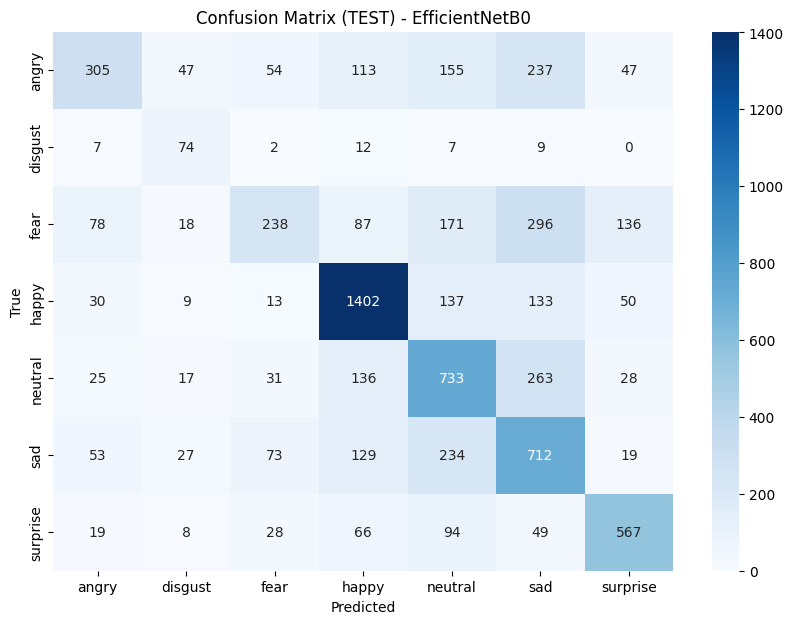

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# =========================
# 0) Make Colab less RAM-hungry
# =========================
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# Optional: mixed precision saves VRAM/RAM on GPU runs
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled")
except Exception as e:
    print("Mixed precision not enabled:", e)

# =========================
# 1) PATHS & SETTINGS
# =========================
train_dir = "/content/datasets/train"
test_dir  = "/content/datasets/test"

IMG_SIZE = (96, 96)
BATCH = 32              # reduce batch to lower memory; you can try 64 if stable
NUM_CLASSES = 7
VAL_SPLIT = 0.12

EPOCHS_STAGE1 = 12
EPOCHS_STAGE2 = 18

LABEL_SMOOTHING = 0.10

# =========================
# 2) Generators (stream from disk)
# =========================
# preprocessing_function runs AFTER PIL loads/resizes the image.
# It receives float32 image in [0,255] by default.
def fer_preprocess(x):
    # x is float32 [0..255], shape (H,W,3)
    # EfficientNet preprocess_input expects RGB in a certain scaling
    return preprocess_input(x)

train_datagen = ImageDataGenerator(
    preprocessing_function=fer_preprocess,
    validation_split=VAL_SPLIT,
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.12,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=fer_preprocess,
    validation_split=VAL_SPLIT
)

test_datagen = ImageDataGenerator(
    preprocessing_function=fer_preprocess
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH,
    subset="training",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH,
    subset="validation",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH,
    shuffle=False
)

classes = list(train_gen.class_indices.keys())
print("Classes:", classes)

# =========================
# 3) Class weights (from streamed labels)
# =========================
y_train_labels = train_gen.classes
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train_labels
)
class_weights = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", class_weights)

# =========================
# 4) Build EfficientNetB0 model
# =========================
def build_model():
    inp = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inp
    )
    backbone.trainable = False  # stage 1

    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Important with mixed precision: force float32 output for numerically stable softmax/loss
    out = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = models.Model(inp, out)
    return model, backbone

model, backbone = build_model()

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1, min_lr=1e-6),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_efficientnetb0.keras", monitor="val_accuracy", mode="max",
                    save_best_only=True, verbose=1)
]

# =========================
# 5) Stage 1 training (frozen backbone)
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

print("\n=== Stage 1: Train head (backbone frozen) ===")
hist1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# =========================
# 6) Stage 2 training (fine-tune last layers)
# =========================
backbone.trainable = True
N_UNFREEZE = 30  # try 20-50; more unfreeze can help but can overfit
for layer in backbone.layers[:-N_UNFREEZE]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

print("\n=== Stage 2: Fine-tune last layers ===")
hist2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1 + EPOCHS_STAGE2,
    initial_epoch=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Load best model checkpoint
model = tf.keras.models.load_model("best_efficientnetb0.keras", compile=False)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=loss_fn, metrics=["accuracy"])

# =========================
# 7) Honest evaluation on TEST
# =========================
val_loss, val_acc = model.evaluate(val_gen, verbose=0)
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"\nBest-checkpoint VAL accuracy:  {val_acc:.4f}")
print(f"Honest TEST accuracy:         {test_acc:.4f}")

# Predictions
y_prob = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

print("\nClassification Report (TEST):\n")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (TEST) - EfficientNetB0")
plt.show()


Mixed precision enabled
Found 25268 images belonging to 7 classes.
Found 3441 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

=== Stage 1: Train head (backbone frozen) ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.2653 - loss: 1.4032
Epoch 1: val_accuracy improved from -inf to 0.37605, saving model to best_efficientnetb0.keras
790/790 ━━━━━━━━━━━━━━━━━━━━ 190s 197ms/step - accuracy: 0.2654 - loss: 1.4031 - val_accuracy: 0.3761 - val_loss: 1.1850 - learning_rate: 3.0000e-04
Epoch 2/12
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.3858 - loss: 1.1611
Epoch 2: val_accuracy improved from 0.37605 to 0.38971, saving model to best_efficientnetb0.keras
790/790 ━━━━━━━━━━━━━━━━━━━━ 120s 152ms/step - accuracy: 0.3858 - loss: 1.1611 - val_accuracy: 0.3897 - val_loss: 1.1789 - learning_rate: 3.0000e-04
Epoch 3/12
790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.3983 - loss: 1.1322
Epoch 3: val_accuracy improved from 0.38971 to 0.40511, saving model to best_efficientnetb0.keras
790/790 ━━━━━━━━━━━━━━━━━━━━ 121s 153ms/step - accuracy: 0.3983 - loss: 1.1322 - val_accuracy: 0.4051 - val_loss: 1.1376 - learning_rate: 3.0000e-0

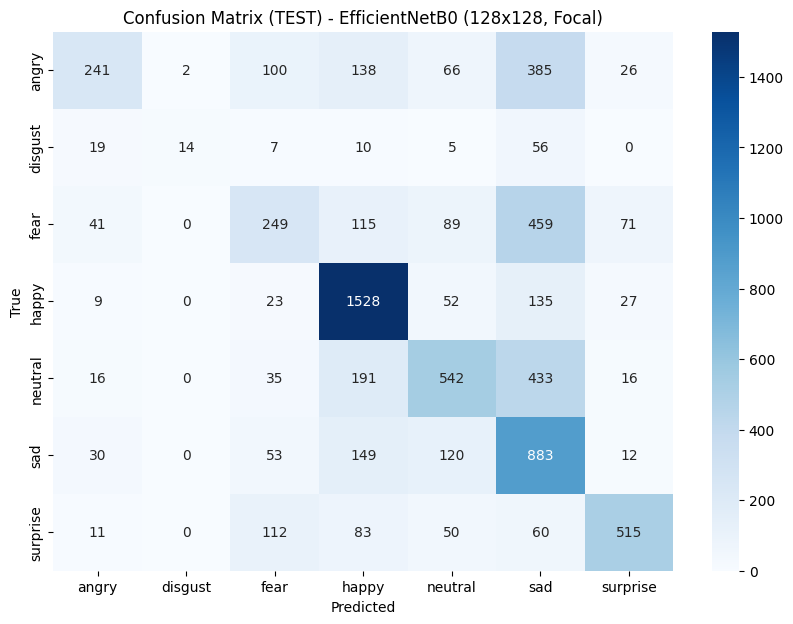

In [ ]:
# EfficientNetB0 FER - "Best bet" combo for ~0.65 (targeted angry/fear) @ 128x128
# Single-script Colab-ready. Keeps your face alignment unchanged (uses same folders).
# Key changes vs your original:
# - IMG_SIZE -> (128,128)
# - Label smoothing reduced
# - Focal Loss (mild alpha boost for angry/fear), remove class_weight
# - In-model augmentation incl. RandomContrast
# - Fine-tune more layers with lower LR
# - Callbacks monitor val_accuracy

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# =========================
# 0) Repro + (optional) mixed precision
# =========================
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled")
except Exception as e:
    print("Mixed precision not enabled:", e)

# =========================
# 1) PATHS & SETTINGS
# =========================
train_dir = "/content/datasets/train"
test_dir  = "/content/datasets/test"

IMG_SIZE = (128, 128)
BATCH = 32          # if you OOM, set 16
NUM_CLASSES = 7
VAL_SPLIT = 0.12

EPOCHS_STAGE1 = 12
EPOCHS_STAGE2 = 20  # a little more room to improve

LABEL_SMOOTHING = 0.05  # was 0.10

# =========================
# 2) Preprocess + Generators
# =========================
def fer_preprocess(x):
    return preprocess_input(x)

# Keep generator aug mild (main aug is inside model)
train_datagen = ImageDataGenerator(
    preprocessing_function=fer_preprocess,
    validation_split=VAL_SPLIT,
    rotation_range=6,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.08,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=fer_preprocess,
    validation_split=VAL_SPLIT
)

test_datagen = ImageDataGenerator(
    preprocessing_function=fer_preprocess
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH,
    subset="training",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH,
    subset="validation",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH,
    shuffle=False
)

classes = list(train_gen.class_indices.keys())
print("Classes:", classes)
assert len(classes) == NUM_CLASSES, "NUM_CLASSES mismatch with folder classes."

# =========================
# 3) Focal Loss (mild boost angry/fear)
# =========================
def categorical_focal_loss(gamma=2.0, alpha=None, label_smoothing=0.0):
    alpha = tf.constant(alpha, dtype=tf.float32) if alpha is not None else None

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)

        if label_smoothing > 0:
            num_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
            y_true = y_true * (1.0 - label_smoothing) + label_smoothing / num_classes

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        pt = tf.reduce_sum(y_true * y_pred, axis=-1)  # prob of true class
        focal = tf.pow(1.0 - pt, gamma)

        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        if alpha is not None:
            at = tf.reduce_sum(y_true * alpha, axis=-1)  # alpha for true class
            return tf.reduce_mean(at * focal * ce)

        return tf.reduce_mean(focal * ce)

    return loss

alpha = np.ones(NUM_CLASSES, dtype=np.float32)
if "angry" in classes:
    alpha[classes.index("angry")] = 1.25
if "fear" in classes:
    alpha[classes.index("fear")] = 1.25
if "disgust" in classes:
    alpha[classes.index("disgust")] = 1.05  # tiny bump only

loss_fn = categorical_focal_loss(gamma=2.0, alpha=alpha, label_smoothing=LABEL_SMOOTHING)

# =========================
# 4) Build model (in-model augmentation + EfficientNetB0)
# =========================
def build_model():
    inp = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomContrast(0.15),
    ], name="aug")

    x_in = aug(inp)

    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=x_in
    )
    backbone.trainable = False  # Stage 1

    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Mixed precision stability: force float32 output
    out = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = models.Model(inp, out)
    return model, backbone

model, backbone = build_model()

callbacks = [
    ReduceLROnPlateau(
        monitor="val_accuracy", factor=0.5, patience=2, verbose=1,
        min_lr=1e-6, mode="max"
    ),
    EarlyStopping(
        monitor="val_accuracy", patience=6, restore_best_weights=True,
        verbose=1, mode="max"
    ),
    ModelCheckpoint(
        "best_efficientnetb0.keras", monitor="val_accuracy", mode="max",
        save_best_only=True, verbose=1
    )
]

# =========================
# 5) Stage 1: Train head (frozen backbone)
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

print("\n=== Stage 1: Train head (backbone frozen) ===")
hist1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks,
    verbose=1
)

# =========================
# 6) Stage 2: Fine-tune last layers (lower LR, unfreeze more)
# =========================
backbone.trainable = True
N_UNFREEZE = 80  # try 60–120; 80 is a strong starting point

for layer in backbone.layers[:-N_UNFREEZE]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss=loss_fn,
    metrics=["accuracy"]
)

print("\n=== Stage 2: Fine-tune last layers ===")
hist2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1 + EPOCHS_STAGE2,
    initial_epoch=EPOCHS_STAGE1,
    callbacks=callbacks,
    verbose=1
)

# =========================
# 7) Load best checkpoint + Evaluate
# =========================
model = tf.keras.models.load_model("best_efficientnetb0.keras", compile=False)
model.compile(optimizer=tf.keras.optimizers.Adam(3e-5), loss=loss_fn, metrics=["accuracy"])

val_loss, val_acc = model.evaluate(val_gen, verbose=0)
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"\nBest-checkpoint VAL accuracy:  {val_acc:.4f}")
print(f"Honest TEST accuracy:         {test_acc:.4f}")

# Predictions
y_prob = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

print("\nClassification Report (TEST):\n")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (TEST) - EfficientNetB0 (128x128, Focal)")
plt.show()


2


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Loading full training set...
Loaded 28709 images from /content/datasets/train
Loading test set (kept untouched)...
Loaded 7178 images from /content/datasets/test

Split: train=25263  val=3446  test=7178
Class weights: {0: 1.0264505119453924, 1: 9.3984375, 2: 1.0011095700416088, 3: 0.5684359741691605, 4: 0.8260471503776607, 5: 0.8491764705882353, 6: 1.293548387096774}

Training: AdamW + CosineDecay + MixUp + Mild Focal CE
Checkpoint: val_accuracy (keeps other classes stable)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2423 - loss: 1.6603
Epoch 1: val_accuracy improved from -inf to 0.16628, saving model to best_adamw_mixup_focal_valacc.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 51s 86ms/step - accuracy: 0.2425 - loss: 1.6599 - val_accuracy: 0.1663 - val_loss: 1.6674
Epoch 2/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3697 - loss: 1.4372
Epoch 2: val_accuracy improved from 0.16628 to 0.44457, saving model to best_adamw_mixup_focal_valacc.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.3698 - loss: 1.4371 - val_accuracy: 0.4446 - val_loss: 1.2589
Epoch 3/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4392 - loss: 1.2883
Epoch 3: val_accuracy did not improve from 0.44457
395/395 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.4393 - loss: 1.2883 - val_accuracy: 0.4428 - val_loss: 1.2298
Epoch 4/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4716 - loss: 1.2113
Epoch 4: val_accuracy improved from 0.44457 to 0.45212, saving model to best_adamw_mixup_focal_valacc.h5


...

395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.6630 - loss: 0.7351 - val_accuracy: 0.6376 - val_loss: 0.7927
Epoch 39/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6712 - loss: 0.7193
Epoch 39: val_accuracy did not improve from 0.63755
395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.6712 - loss: 0.7193 - val_accuracy: 0.6370 - val_loss: 0.7759
Epoch 40/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6621 - loss: 0.7537
Epoch 40: val_accuracy improved from 0.63755 to 0.63871, saving model to best_adamw_mixup_focal_valacc.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.6621 - loss: 0.7537 - val_accuracy: 0.6387 - val_loss: 0.7671
Epoch 41/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6612 - loss: 0.7255
Epoch 41: val_accuracy did not improve from 0.63871
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.6612 - loss: 0.7255 - val_accuracy: 0.6381 - val_loss: 0.7790
Epoch 42/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6724 - loss: 0.7293
Epoch 42: val_accuracy did not improve from 0.63871
395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.6724 - loss: 0.7293 - val_accuracy: 0.6370 - val_loss: 0.7811
Epoch 43/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6783 - loss: 0.7145
Epoch 43: val_accuracy did not improve from 0.63871
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.6783 - loss: 0.7145 - val_accuracy: 0.6364 - val_loss: 0.7806
Epoch 44/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6827 - loss: 0.6994
Epoch 44: val_ac

395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.6714 - loss: 0.7289 - val_accuracy: 0.6393 - val_loss: 0.7796
Epoch 46/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6825 - loss: 0.7159
Epoch 46: val_accuracy improved from 0.63929 to 0.64074, saving model to best_adamw_mixup_focal_valacc.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.6825 - loss: 0.7159 - val_accuracy: 0.6407 - val_loss: 0.7726
Epoch 47/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6889 - loss: 0.6900
Epoch 47: val_accuracy improved from 0.64074 to 0.64219, saving model to best_adamw_mixup_focal_valacc.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.6889 - loss: 0.6900 - val_accuracy: 0.6422 - val_loss: 0.7779
Epoch 48/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6756 - loss: 0.7221
Epoch 48: val_accuracy did not improve from 0.64219
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.6756 - loss: 0.7221 - val_accuracy: 0.6405 - val_loss: 0.7770
Epoch 49/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6856 - loss: 0.6928
Epoch 49: val_accuracy did not improve from 0.64219
395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.6856 - loss: 0.6928 - val_accuracy: 0.6387 - val_loss: 0.7744
Epoch 50/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6770 - loss: 0.7189
Epoch 50: val_accuracy did not improve from 0.64219
395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.6770 - loss: 0.7189 - val_accuracy: 0.6393 - val_loss: 0.7752
Restoring model weights from the end of the best epoch: 47.

Honest TEST accuracy: 0.6431

Classificatio

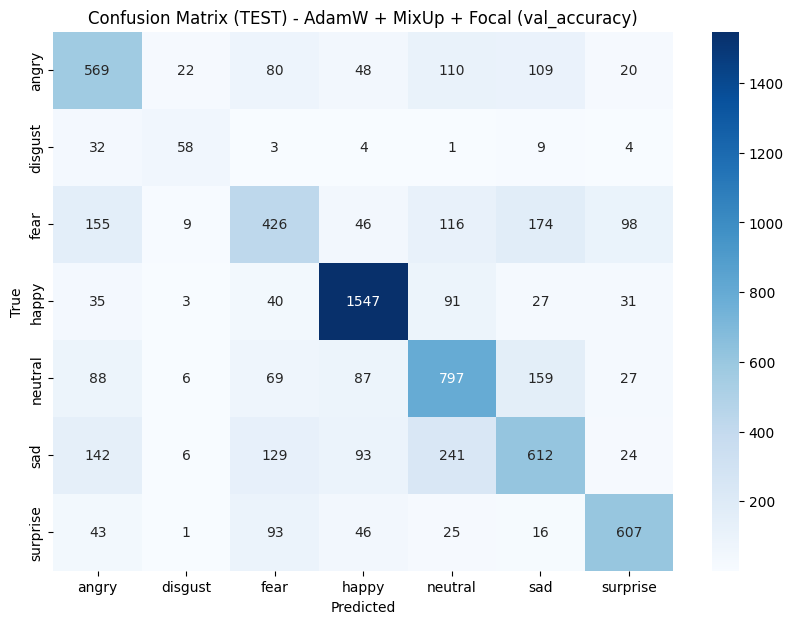

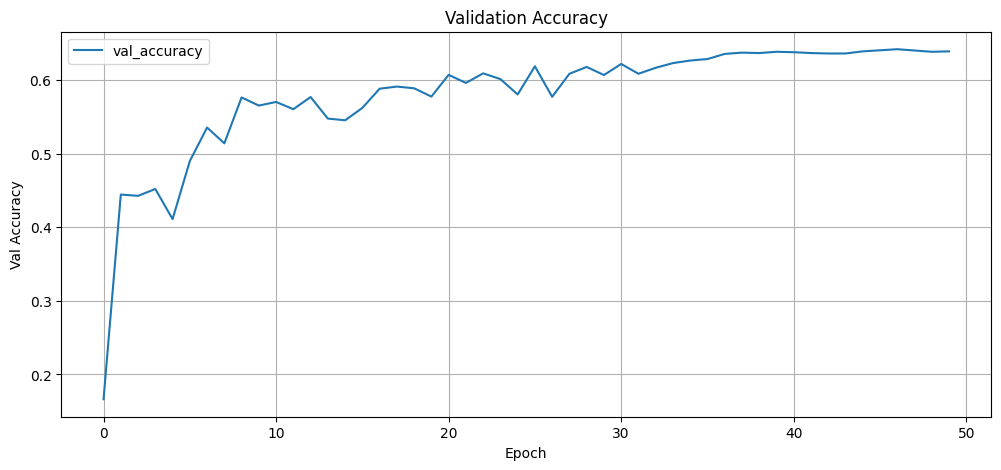


Saved final best model to: final_best_model_accuracy_plus.keras
Best checkpoint: best_adamw_mixup_focal_valacc.h5


In [ ]:
"""
FER-2013 Emotion Recognition
Dlib 68-Landmark Face Alignment + Mini-Xception CNN

Goal:
- Increase overall accuracy
- Improve fear recall WITHOUT destroying other classes
- Do NOT print fear recall or checkpoint on it

Key changes vs your baseline:
1) Largest-face selection (avoid rects[0] bug)
2) AdamW + CosineDecay LR schedule (better generalization)
3) MixUp training (reduces confusion, helps fear vs sad/neutral/surprise)
4) Mild Focal Loss + class_weight (gentle focus on hard examples)
5) Checkpoint on val_accuracy (keeps other classes stable)
"""

# ===========================================
# 1. IMPORTS
# ===========================================
import os
import math
import urllib.request
import subprocess
import numpy as np
import cv2
import dlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, SeparableConv2D, BatchNormalization, ReLU, Add,
    GlobalAveragePooling2D, Dropout, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ===========================================
# 2. PATHS & SETTINGS
# ===========================================
train_dir = "/content/datasets/train"
test_dir  = "/content/datasets/test"

img_size = (48, 48)
num_classes = 7
batch_size = 64
epochs = 50          # a bit longer; cosine schedule + early stopping handles it
val_size = 0.12

label_smoothing = 0.05   # mild (0.10 was a bit high for fear)
weight_decay_l2 = 1e-4

# MixUp strength (0.10–0.30 typical)
MIXUP_ALPHA = 0.2

# Mild focal loss (keep small to avoid collapse)
FOCAL_GAMMA = 1.5

# ===========================================
# 3. CHECK CLASSES
# ===========================================
if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"train_dir not found: {train_dir}")
if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"test_dir not found: {test_dir}")

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", classes)
if len(classes) != num_classes:
    print(f"WARNING: num_classes={num_classes}, but found {len(classes)} folders.")

# ===========================================
# 4. DLIB SETUP (download shape predictor if missing)
# ===========================================
PRED_PATH = "shape_predictor_68_face_landmarks.dat"
PRED_BZ2  = "shape_predictor_68_face_landmarks.dat.bz2"
PRED_URL  = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"

def ensure_dlib_predictor():
    if os.path.exists(PRED_PATH):
        return
    print("Downloading Dlib shape predictor...")
    if not os.path.exists(PRED_BZ2):
        urllib.request.urlretrieve(PRED_URL, PRED_BZ2)
    print("Decompressing predictor (bz2)...")
    try:
        subprocess.run(["bzip2", "-dk", PRED_BZ2], check=True)
    except Exception as e:
        raise RuntimeError("Failed to decompress .bz2. Install bzip2 or decompress manually.") from e

ensure_dlib_predictor()

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PRED_PATH)

# ===========================================
# 5. PREPROCESSING: ALIGNMENT + CLAHE + STANDARDIZATION
# ===========================================
def preprocess_gray(gray48: np.ndarray) -> np.ndarray:
    """CLAHE + per-image standardization."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    g = clahe.apply(gray48)
    g = g.astype(np.float32)
    mean, std = float(g.mean()), float(g.std())
    g = (g - mean) / (std + 1e-6)
    return g

def align_face_dlib(img, output_size=(48,48), expand_ratio=0.30):
    """
    Face alignment using:
      - Dlib HOG detector
      - 68 landmarks
      - Eye-alignment rotation + expanded crop
    Returns: float32 (48,48) after preprocess_gray
    """
    if img is None:
        return np.zeros(output_size, np.float32)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rects = detector(gray, 1)

    if len(rects) == 0:
        g = cv2.resize(gray, output_size)
        return preprocess_gray(g)

    # IMPORTANT: choose the largest face (fixes rects[0] issue)
    rect = max(rects, key=lambda r: r.width() * r.height())

    shape = predictor(gray, rect)
    shape_np = np.array([[p.x, p.y] for p in shape.parts()], dtype=np.int32)

    left_eye  = shape_np[36:42].mean(axis=0).astype(np.int32)
    right_eye = shape_np[42:48].mean(axis=0).astype(np.int32)

    dy = int(right_eye[1] - left_eye[1])
    dx = int(right_eye[0] - left_eye[0])
    angle = float(np.degrees(np.arctan2(dy, dx)))

    eye_center = tuple(((left_eye + right_eye) // 2).tolist())
    rot_mat = cv2.getRotationMatrix2D(eye_center, angle, 1.0)
    rotated = cv2.warpAffine(
        gray, rot_mat, (gray.shape[1], gray.shape[0]),
        flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE
    )

    x, y, w, h = rect.left(), rect.top(), rect.width(), rect.height()
    x = max(0, int(x - w * expand_ratio))
    y = max(0, int(y - h * expand_ratio))
    w = int(w * (1 + 2 * expand_ratio))
    h = int(h * (1 + 2 * expand_ratio))

    x2 = min(rotated.shape[1], x + w)
    y2 = min(rotated.shape[0], y + h)

    crop = rotated[y:y2, x:x2]
    if crop.size == 0:
        g = cv2.resize(gray, output_size)
        return preprocess_gray(g)

    aligned = cv2.resize(crop, output_size)
    return preprocess_gray(aligned)

# ===========================================
# 6. LOAD DATASET
# ===========================================
def load_dataset(folder):
    X, y = [], []
    class_map = {cls: i for i, cls in enumerate(classes)}

    for cls in classes:
        folder_cls = os.path.join(folder, cls)
        if not os.path.isdir(folder_cls):
            continue

        for file in os.listdir(folder_cls):
            img_path = os.path.join(folder_cls, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            aligned = align_face_dlib(img, output_size=img_size)
            X.append(aligned)
            y.append(class_map[cls])

    X = np.array(X, dtype=np.float32).reshape(-1, 48, 48, 1)
    y = tf.keras.utils.to_categorical(y, num_classes)
    print(f"Loaded {X.shape[0]} images from {folder}")
    return X, y

print("\nLoading full training set...")
X_all, y_all = load_dataset(train_dir)

print("Loading test set (kept untouched)...")
X_test, y_test = load_dataset(test_dir)

# Train/Val split (stratified)
y_all_labels = np.argmax(y_all, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=val_size,
    random_state=42,
    stratify=y_all_labels
)
print(f"\nSplit: train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

# Class weights (helps minority like disgust; keep it)
y_train_labels = np.argmax(y_train, axis=1)
cw = compute_class_weight(class_weight="balanced", classes=np.arange(num_classes), y=y_train_labels)
class_weights = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", class_weights)

# ===========================================
# 7. DATA AUGMENTATION
# ===========================================
datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.12,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15)  # small brightness jitter (fear-friendly)
)
datagen.fit(X_train)

# ===========================================
# 8. MIXUP WRAPPER
# ===========================================
def mixup_batch(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y
    lam = np.random.beta(alpha, alpha)
    idx = np.random.permutation(x.shape[0])
    x2, y2 = x[idx], y[idx]
    return lam * x + (1 - lam) * x2, lam * y + (1 - lam) * y2

class MixupGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_gen, alpha=0.2):
        self.base_gen = base_gen
        self.alpha = alpha
    def __len__(self):
        return len(self.base_gen)
    def __getitem__(self, i):
        x, y = self.base_gen[i]
        return mixup_batch(x, y, self.alpha)

# ===========================================
# 9. MINI-XCEPTION
# ===========================================
def mini_xception(input_shape=(48,48,1), n_classes=7, wd=1e-4):
    inp = Input(input_shape)

    x = Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(wd))(inp)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(64, (3,3), strides=2, padding='same', kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    def res_block(x, filters):
        res = Conv2D(filters, (1,1), strides=2, padding='same', kernel_regularizer=l2(wd))(x)

        y = SeparableConv2D(filters, (3,3), padding='same',
                            depthwise_regularizer=l2(wd), pointwise_regularizer=l2(wd))(x)
        y = BatchNormalization()(y)
        y = ReLU()(y)

        y = SeparableConv2D(filters, (3,3), strides=2, padding='same',
                            depthwise_regularizer=l2(wd), pointwise_regularizer=l2(wd))(y)
        y = BatchNormalization()(y)

        out = Add()([res, y])
        out = ReLU()(out)
        return out

    x = res_block(x, 128)
    x = res_block(x, 256)
    x = res_block(x, 512)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    out = Dense(n_classes, activation="softmax", kernel_regularizer=l2(wd))(x)
    return Model(inp, out)

# ===========================================
# 10. LOSS: Mild Focal CE with label smoothing
# ===========================================
def focal_categorical_loss(gamma=1.5, label_smoothing=0.0):
    ce = tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing, reduction="none")
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        base = ce(y_true, y_pred)  # per-sample
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)  # prob of true class
        focal = tf.pow(1.0 - pt, gamma)
        return tf.reduce_mean(focal * base)
    return loss

loss_fn = focal_categorical_loss(gamma=FOCAL_GAMMA, label_smoothing=label_smoothing)

# ===========================================
# 11. OPTIMIZER: AdamW + CosineDecay
# ===========================================
steps_per_epoch = math.ceil(len(X_train) / batch_size)
total_steps = steps_per_epoch * epochs

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=8e-4,
    decay_steps=total_steps,
    alpha=1e-2
)
optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4)

# ===========================================
# 12. TRAIN
# ===========================================
tf.keras.backend.clear_session()
model = mini_xception(input_shape=(48,48,1), n_classes=num_classes, wd=weight_decay_l2)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

ckpt_path = "best_adamw_mixup_focal_valacc.h5"

callbacks = [
    ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_accuracy", mode="max", verbose=1),
    EarlyStopping(monitor="val_accuracy", mode="max", patience=10, restore_best_weights=True, verbose=1),
]

base_gen = datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True)
train_gen = MixupGenerator(base_gen, alpha=MIXUP_ALPHA)

print("\n==============================")
print("Training: AdamW + CosineDecay + MixUp + Mild Focal CE")
print("Checkpoint: val_accuracy (keeps other classes stable)")
print("==============================")

history = model.fit(
    train_gen,
    validation_data=(X_val, y_val),
    epochs=epochs,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# Load best checkpoint into fresh model (safer)
best_model = mini_xception(input_shape=(48,48,1), n_classes=num_classes, wd=weight_decay_l2)
best_model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])
best_model.load_weights(ckpt_path)

# ===========================================
# 13. EVALUATE ON TEST (HONEST)
# ===========================================
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nHonest TEST accuracy: {test_acc:.4f}")

y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report (TEST):\n")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (TEST) - AdamW + MixUp + Focal (val_accuracy)")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid(True)
plt.show()

best_model.save("final_best_model_accuracy_plus.keras")
print("\nSaved final best model to: final_best_model_accuracy_plus.keras")
print(f"Best checkpoint: {ckpt_path}")


# Semi_Final_Code

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Loading full training set...
Loaded 28709 images from /content/datasets/train
Loading test set (kept untouched)...
Loaded 7178 images from /content/datasets/test

Split: train=25263  val=3446  test=7178
Class weights: {0: 1.0264505119453924, 1: 9.3984375, 2: 1.0011095700416088, 3: 0.5684359741691605, 4: 0.8260471503776607, 5: 0.8491764705882353, 6: 1.293548387096774}

Training with optimizer: sgd
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2220 - loss: 1.6583
Epoch 1: val_accuracy improved from -inf to 0.18543, saving model to best_sgd.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 39s 75ms/step - accuracy: 0.2221 - loss: 1.6580 - val_accuracy: 0.1854 - val_loss: 1.6406
Epoch 2/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3065 - loss: 1.4862
Epoch 2: val_accuracy improved from 0.18543 to 0.30673, saving model to best_sgd.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.3066 - loss: 1.4861 - val_accuracy: 0.3067 - val_loss: 1.4460
Epoch 3/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3614 - loss: 1.4013
Epoch 3: val_accuracy improved from 0.30673 to 0.40627, saving model to best_sgd.h5


...

395/395 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.5354 - loss: 1.0973 - val_accuracy: 0.5670 - val_loss: 0.9792
Epoch 26/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5445 - loss: 1.0489
Epoch 26: val_accuracy did not improve from 0.56703
395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.5445 - loss: 1.0489 - val_accuracy: 0.5543 - val_loss: 1.0012
Epoch 27/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5386 - loss: 1.0551
Epoch 27: val_accuracy did not improve from 0.56703
395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.5386 - loss: 1.0551 - val_accuracy: 0.5519 - val_loss: 1.0052
Epoch 28/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5531 - loss: 1.0355
Epoch 28: val_accuracy did not improve from 0.56703
395/395 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.5531 - loss: 1.0355 - val_accuracy: 0.5609 - val_loss: 0.9763
Epoch 29/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5411 - loss: 1.0574
Epoch 29: val_ac

395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.5508 - loss: 1.0387 - val_accuracy: 0.5737 - val_loss: 0.9731
Epoch 34/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5572 - loss: 1.0203
Epoch 34: val_accuracy improved from 0.57371 to 0.57487, saving model to best_adagrad.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.5572 - loss: 1.0203 - val_accuracy: 0.5749 - val_loss: 0.9460
Epoch 35/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5591 - loss: 1.0331
Epoch 35: val_accuracy did not improve from 0.57487
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.5592 - loss: 1.0331 - val_accuracy: 0.5749 - val_loss: 0.9609
Epoch 36/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5634 - loss: 1.0178
Epoch 36: val_accuracy did not improve from 0.57487
395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.5634 - loss: 1.0178 - val_accuracy: 0.5670 - val_loss: 0.9689
Epoch 37/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5634 - loss: 1.0120
Epoch 37: val_accuracy did not improve from 0.57487
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.5634 - loss: 1.0120 - val_accuracy: 0.5627 - val_loss: 0.9517
Epoch 38/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5542 - loss: 1.0150
Epoch 38: val_ac

395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.5767 - loss: 0.9961 - val_accuracy: 0.5801 - val_loss: 0.9475
Epoch 42/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5791 - loss: 0.9800
Epoch 42: val_accuracy did not improve from 0.58009
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.5791 - loss: 0.9800 - val_accuracy: 0.5746 - val_loss: 0.9632
Epoch 43/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5774 - loss: 0.9889
Epoch 43: val_accuracy improved from 0.58009 to 0.59954, saving model to best_adagrad.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.5774 - loss: 0.9889 - val_accuracy: 0.5995 - val_loss: 0.9146
Epoch 44/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5709 - loss: 1.0068
Epoch 44: val_accuracy did not improve from 0.59954
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.5709 - loss: 1.0068 - val_accuracy: 0.5972 - val_loss: 0.9100
Epoch 45/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5729 - loss: 0.9794
Epoch 45: val_accuracy did not improve from 0.59954
395/395 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.5729 - loss: 0.9794 - val_accuracy: 0.5804 - val_loss: 0.9323
Epoch 46/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5867 - loss: 0.9598
Epoch 46: val_accuracy did not improve from 0.59954
395/395 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.5866 - loss: 0.9599 - val_accuracy: 0.5775 - val_loss: 0.9480
Epoch 47/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5862 - loss: 0.9507
Epoch 47: val_ac

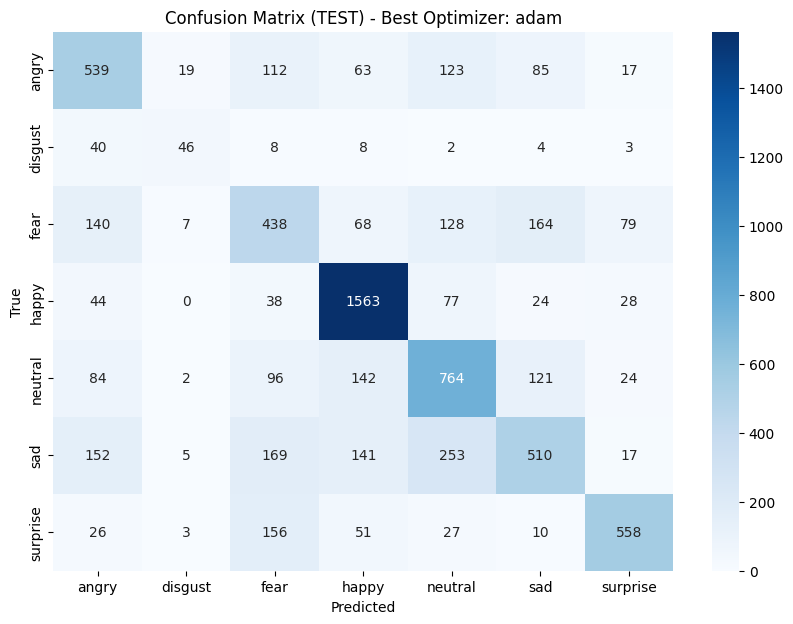

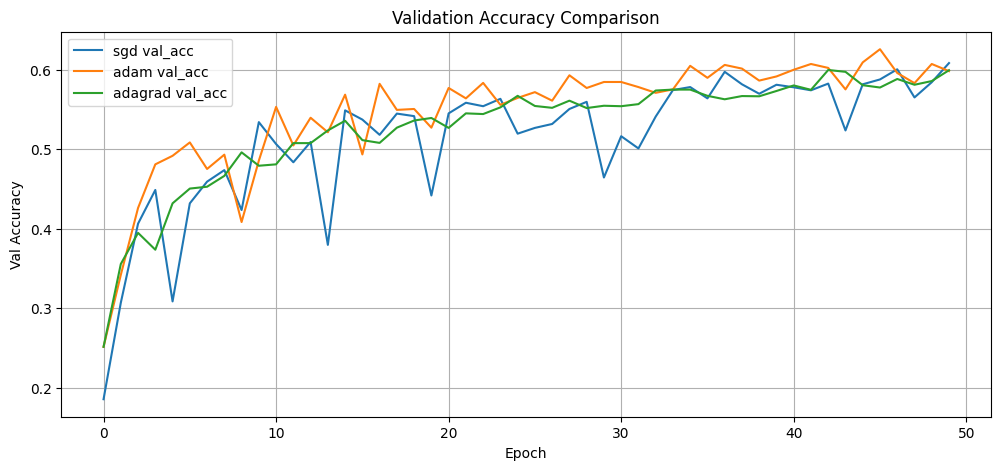

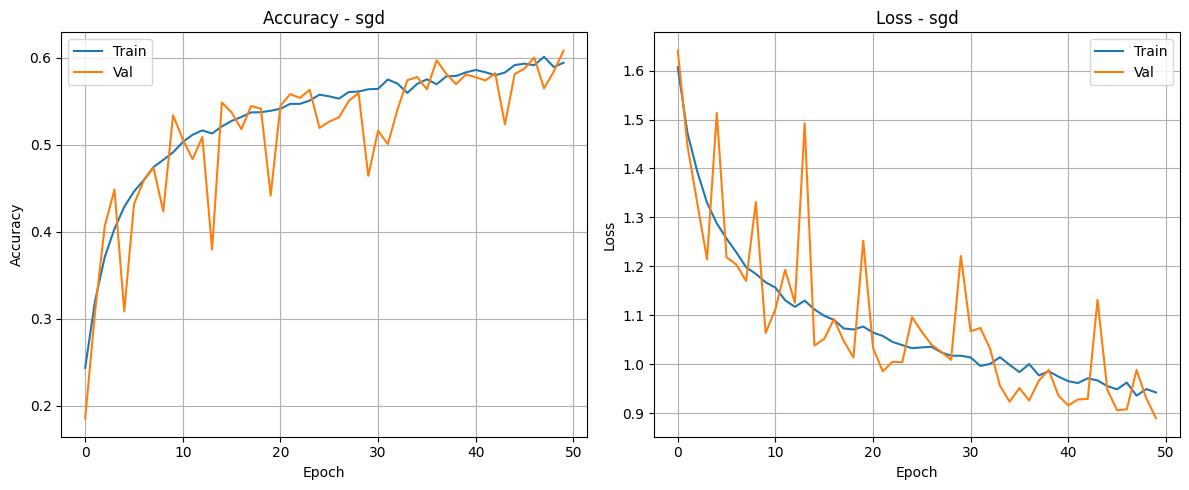

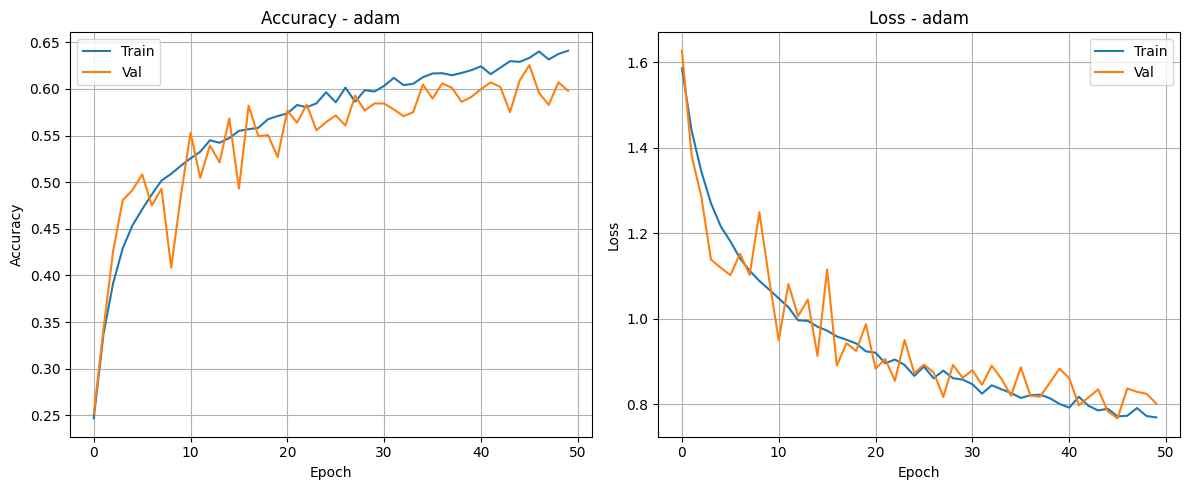

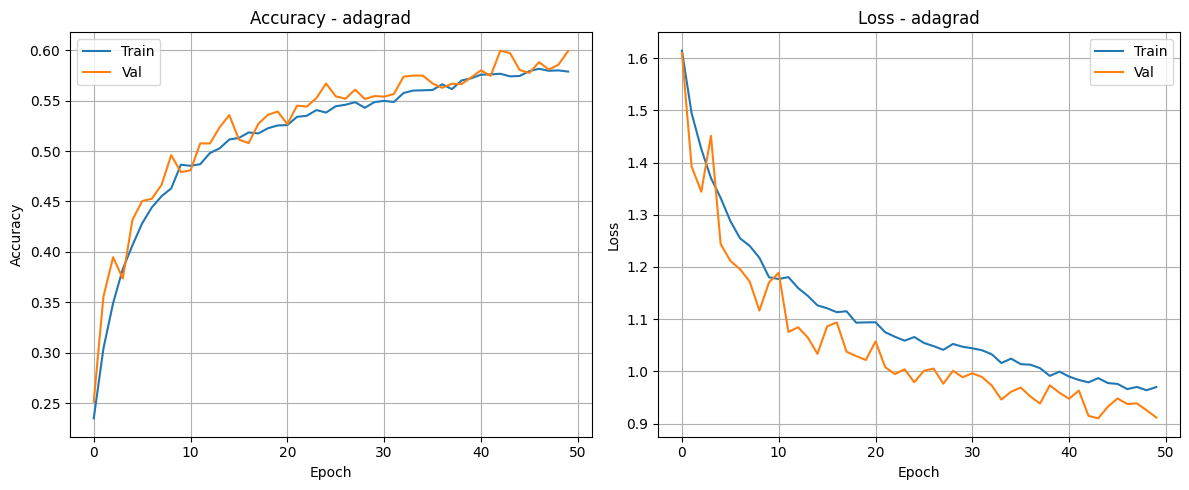


Saved final best model to: final_best_model_best_optimizer.keras


In [ ]:
"""
FER-2013 Emotion Recognition
Dlib 68-Landmark Face Alignment + Mini-Xception CNN

Goal:
- Increase overall accuracy
- Improve fear recall WITHOUT destroying other classes
- Do NOT print fear recall or checkpoint on it

Key changes vs your baseline:
1) Largest-face selection (avoid rects[0] bug)
2) MixUp training
3) Mild Focal Loss + class_weight
4) Checkpoint on val_accuracy

USER REQUESTED EDITS ONLY:
- FOCAL_GAMMA = 1.7
- MIXUP_ALPHA = 0.25
- Add optimizer comparison: SGD(no momentum) vs Adam vs Adagrad
- Print optimizer comparison table
- Plot validation accuracy comparison curve (like attached)
- Plot accuracy/loss (train/val) for each optimizer (like attached)
"""

# ===========================================
# 1. IMPORTS
# ===========================================
import os
import math
import urllib.request
import subprocess
import numpy as np
import cv2
import dlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, SeparableConv2D, BatchNormalization, ReLU, Add,
    GlobalAveragePooling2D, Dropout, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ===========================================
# 2. PATHS & SETTINGS
# ===========================================
train_dir = "/content/datasets/train"
test_dir  = "/content/datasets/test"

img_size = (48, 48)
num_classes = 7
batch_size = 64
epochs = 50
val_size = 0.12

label_smoothing = 0.05
weight_decay_l2 = 1e-4

# USER EDIT #1
MIXUP_ALPHA = 0.25

# USER EDIT #2
FOCAL_GAMMA = 1.7

# ===========================================
# 3. CHECK CLASSES
# ===========================================
if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"train_dir not found: {train_dir}")
if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"test_dir not found: {test_dir}")

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", classes)
if len(classes) != num_classes:
    print(f"WARNING: num_classes={num_classes}, but found {len(classes)} folders.")

# ===========================================
# 4. DLIB SETUP (download shape predictor if missing)
# ===========================================
PRED_PATH = "shape_predictor_68_face_landmarks.dat"
PRED_BZ2  = "shape_predictor_68_face_landmarks.dat.bz2"
PRED_URL  = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"

def ensure_dlib_predictor():
    if os.path.exists(PRED_PATH):
        return
    print("Downloading Dlib shape predictor...")
    if not os.path.exists(PRED_BZ2):
        urllib.request.urlretrieve(PRED_URL, PRED_BZ2)
    print("Decompressing predictor (bz2)...")
    try:
        subprocess.run(["bzip2", "-dk", PRED_BZ2], check=True)
    except Exception as e:
        raise RuntimeError("Failed to decompress .bz2. Install bzip2 or decompress manually.") from e

ensure_dlib_predictor()

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PRED_PATH)

# ===========================================
# 5. PREPROCESSING: ALIGNMENT + CLAHE + STANDARDIZATION
# ===========================================
def preprocess_gray(gray48: np.ndarray) -> np.ndarray:
    """CLAHE + per-image standardization."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    g = clahe.apply(gray48)
    g = g.astype(np.float32)
    mean, std = float(g.mean()), float(g.std())
    g = (g - mean) / (std + 1e-6)
    return g

def align_face_dlib(img, output_size=(48,48), expand_ratio=0.30):
    """
    Face alignment using:
      - Dlib HOG detector
      - 68 landmarks
      - Eye-alignment rotation + expanded crop
    Returns: float32 (48,48) after preprocess_gray
    """
    if img is None:
        return np.zeros(output_size, np.float32)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rects = detector(gray, 1)

    if len(rects) == 0:
        g = cv2.resize(gray, output_size)
        return preprocess_gray(g)

    # choose the largest face (fixes rects[0] issue)
    rect = max(rects, key=lambda r: r.width() * r.height())

    shape = predictor(gray, rect)
    shape_np = np.array([[p.x, p.y] for p in shape.parts()], dtype=np.int32)

    left_eye  = shape_np[36:42].mean(axis=0).astype(np.int32)
    right_eye = shape_np[42:48].mean(axis=0).astype(np.int32)

    dy = int(right_eye[1] - left_eye[1])
    dx = int(right_eye[0] - left_eye[0])
    angle = float(np.degrees(np.arctan2(dy, dx)))

    eye_center = tuple(((left_eye + right_eye) // 2).tolist())
    rot_mat = cv2.getRotationMatrix2D(eye_center, angle, 1.0)
    rotated = cv2.warpAffine(
        gray, rot_mat, (gray.shape[1], gray.shape[0]),
        flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE
    )

    x, y, w, h = rect.left(), rect.top(), rect.width(), rect.height()
    x = max(0, int(x - w * expand_ratio))
    y = max(0, int(y - h * expand_ratio))
    w = int(w * (1 + 2 * expand_ratio))
    h = int(h * (1 + 2 * expand_ratio))

    x2 = min(rotated.shape[1], x + w)
    y2 = min(rotated.shape[0], y + h)

    crop = rotated[y:y2, x:x2]
    if crop.size == 0:
        g = cv2.resize(gray, output_size)
        return preprocess_gray(g)

    aligned = cv2.resize(crop, output_size)
    return preprocess_gray(aligned)

# ===========================================
# 6. LOAD DATASET
# ===========================================
def load_dataset(folder):
    X, y = [], []
    class_map = {cls: i for i, cls in enumerate(classes)}

    for cls in classes:
        folder_cls = os.path.join(folder, cls)
        if not os.path.isdir(folder_cls):
            continue

        for file in os.listdir(folder_cls):
            img_path = os.path.join(folder_cls, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            aligned = align_face_dlib(img, output_size=img_size)
            X.append(aligned)
            y.append(class_map[cls])

    X = np.array(X, dtype=np.float32).reshape(-1, 48, 48, 1)
    y = tf.keras.utils.to_categorical(y, num_classes)
    print(f"Loaded {X.shape[0]} images from {folder}")
    return X, y

print("\nLoading full training set...")
X_all, y_all = load_dataset(train_dir)

print("Loading test set (kept untouched)...")
X_test, y_test = load_dataset(test_dir)

# Train/Val split (stratified)
y_all_labels = np.argmax(y_all, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=val_size,
    random_state=42,
    stratify=y_all_labels
)
print(f"\nSplit: train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

# Class weights (keep it exactly as your code)
y_train_labels = np.argmax(y_train, axis=1)
cw = compute_class_weight(class_weight="balanced", classes=np.arange(num_classes), y=y_train_labels)
class_weights = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", class_weights)

# ===========================================
# 7. DATA AUGMENTATION
# ===========================================
datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.12,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15)
)
datagen.fit(X_train)

# ===========================================
# 8. MIXUP WRAPPER
# ===========================================
def mixup_batch(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y
    lam = np.random.beta(alpha, alpha)
    idx = np.random.permutation(x.shape[0])
    x2, y2 = x[idx], y[idx]
    return lam * x + (1 - lam) * x2, lam * y + (1 - lam) * y2

class MixupGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_gen, alpha=0.2):
        self.base_gen = base_gen
        self.alpha = alpha
    def __len__(self):
        return len(self.base_gen)
    def __getitem__(self, i):
        x, y = self.base_gen[i]
        return mixup_batch(x, y, self.alpha)

# ===========================================
# 9. MINI-XCEPTION
# ===========================================
def mini_xception(input_shape=(48,48,1), n_classes=7, wd=1e-4):
    inp = Input(input_shape)

    x = Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(wd))(inp)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(64, (3,3), strides=2, padding='same', kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    def res_block(x, filters):
        res = Conv2D(filters, (1,1), strides=2, padding='same', kernel_regularizer=l2(wd))(x)

        y = SeparableConv2D(filters, (3,3), padding='same',
                            depthwise_regularizer=l2(wd), pointwise_regularizer=l2(wd))(x)
        y = BatchNormalization()(y)
        y = ReLU()(y)

        y = SeparableConv2D(filters, (3,3), strides=2, padding='same',
                            depthwise_regularizer=l2(wd), pointwise_regularizer=l2(wd))(y)
        y = BatchNormalization()(y)

        out = Add()([res, y])
        out = ReLU()(out)
        return out

    x = res_block(x, 128)
    x = res_block(x, 256)
    x = res_block(x, 512)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    out = Dense(n_classes, activation="softmax", kernel_regularizer=l2(wd))(x)
    return Model(inp, out)

# ===========================================
# 10. LOSS: Mild Focal CE with label smoothing
# ===========================================
def focal_categorical_loss(gamma=1.5, label_smoothing=0.0):
    ce = tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing, reduction="none")
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        base = ce(y_true, y_pred)  # per-sample
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)  # prob of true class
        focal = tf.pow(1.0 - pt, gamma)
        return tf.reduce_mean(focal * base)
    return loss

loss_fn = focal_categorical_loss(gamma=FOCAL_GAMMA, label_smoothing=label_smoothing)

# ===========================================
# 11. OPTIMIZERS TO COMPARE (as requested)
# ===========================================
def make_optimizer(name: str):
    name = name.lower().strip()
    if name == "sgd":
        return tf.keras.optimizers.SGD(learning_rate=0.03, momentum=0.0, nesterov=False)
    if name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=3e-4)
    if name == "adagrad":
        return tf.keras.optimizers.Adagrad(learning_rate=0.01)
    raise ValueError(f"Unknown optimizer: {name}")

# ===========================================
# 12. TRAIN ONE RUN (per optimizer)
# ===========================================
def train_with_optimizer(opt_name: str):
    tf.keras.backend.clear_session()

    model = mini_xception(input_shape=(48,48,1), n_classes=num_classes, wd=weight_decay_l2)
    optimizer = make_optimizer(opt_name)

    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

    ckpt_path = f"best_{opt_name}.h5"
    callbacks = [
        ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_accuracy", mode="max", verbose=1),
        EarlyStopping(monitor="val_accuracy", mode="max", patience=10, restore_best_weights=True, verbose=1),
    ]

    base_gen = datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True)
    train_gen = MixupGenerator(base_gen, alpha=MIXUP_ALPHA)

    print(f"\n==============================")
    print(f"Training with optimizer: {opt_name}")
    print(f"==============================")

    history = model.fit(
        train_gen,
        validation_data=(X_val, y_val),
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )

    best_val_acc = float(np.max(history.history["val_accuracy"]))
    best_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)

    return model, history, best_val_acc, best_epoch, ckpt_path

# ===========================================
# 13. RUN COMPARISON
# ===========================================
optimizers_to_test = ["sgd", "adam", "adagrad"]
results = []
histories = {}

trained_models = {}

for opt in optimizers_to_test:
    model, history, best_val_acc, best_epoch, ckpt_path = train_with_optimizer(opt)
    results.append((opt, best_val_acc, best_epoch, ckpt_path))
    histories[opt] = history
    trained_models[opt] = model

# Print comparison table
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print("\n\n=== Optimizer Comparison (by best Val Accuracy) ===")
print(f"{'Optimizer':<10} | {'Best Val Acc':<12} | {'Best Epoch':<10} | {'Checkpoint'}")
print("-"*70)
for opt, acc, ep, ck in results_sorted:
    print(f"{opt:<10} | {acc:<12.4f} | {ep:<10d} | {ck}")

best_opt, best_acc, best_ep, best_ckpt = results_sorted[0]
print(f"\nBEST OPTIMIZER: {best_opt}  (best val acc={best_acc:.4f} at epoch {best_ep})")
print(f"Best checkpoint saved at: {best_ckpt}")

# Load best weights into a fresh model (safer)
best_model = mini_xception(input_shape=(48,48,1), n_classes=num_classes, wd=weight_decay_l2)
best_model.compile(optimizer=make_optimizer(best_opt), loss=loss_fn, metrics=["accuracy"])
best_model.load_weights(best_ckpt)

# ===========================================
# 14. EVALUATE ON TEST USING BEST OPT
# ===========================================
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\n TEST accuracy (best optimizer={best_opt}): {test_acc:.4f}")

y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report (TEST):\n")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (TEST) - Best Optimizer: {best_opt}")
plt.show()

# ===========================================
# 15. PLOT 1: Validation Accuracy Comparison (like your attached)
# ===========================================
plt.figure(figsize=(12,5))
for opt in optimizers_to_test:
    plt.plot(histories[opt].history["val_accuracy"], label=f"{opt} val_acc")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ===========================================
# 16. PLOT 2: For each optimizer -> Accuracy + Loss (train/val) like your attached
# ===========================================
for opt in optimizers_to_test:
    h = histories[opt].history

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(h["accuracy"], label="Train")
    plt.plot(h["val_accuracy"], label="Val")
    plt.title(f"Accuracy - {opt}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(h["loss"], label="Train")
    plt.plot(h["val_loss"], label="Val")
    plt.title(f"Loss - {opt}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Save final best model
best_model.save("final_best_model_best_optimizer.keras")
print("\nSaved final best model to: final_best_model_best_optimizer.keras")


# Final_Code


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Decompressing predictor (bz2)...

Loading full training set...
Loaded 28709 images from /content/datasets/train
Loading test set (kept untouched)...
Loaded 7178 images from /content/datasets/test

Split: train=25263  val=3446  test=7178
Class weights (raw): {0: 1.0264505119453924, 1: 9.3984375, 2: 1.0011095700416088, 3: 0.5684359741691605, 4: 0.8260471503776607, 5: 0.8491764705882353, 6: 1.293548387096774}
Class weights (CAPPED at 2.5): {0: 1.0264505119453924, 1: 2.5, 2: 1.0011095700416088, 3: 0.5684359741691605, 4: 0.8260471503776607, 5: 0.8491764705882353, 6: 1.293548387096774}

Training with optimizer: sgd
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2094 - loss: 1.5375
Epoch 1: val_accuracy improved from -inf to 0.25508, saving model to best_sgd.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 64s 117ms/step - accuracy: 0.2095 - loss: 1.5372 - val_accuracy: 0.2551 - val_loss: 1.6038
Epoch 2/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2858 - loss: 1.3709
Epoch 2: val_accuracy improved from 0.25508 to 0.28003, saving model to best_sgd.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.2859 - loss: 1.3708 - val_accuracy: 0.2800 - val_loss: 1.7402
Epoch 3/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3655 - loss: 1.2815
Epoch 3: val_accuracy improved from 0.28003 to 0.37522, saving model to best_sgd.h5


...

395/395 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.6322 - loss: 0.6917 - val_accuracy: 0.6242 - val_loss: 0.7421
Epoch 35/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6377 - loss: 0.6722
Epoch 35: val_accuracy improved from 0.62420 to 0.62681, saving model to best_adamw.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.6377 - loss: 0.6722 - val_accuracy: 0.6268 - val_loss: 0.7302
Epoch 36/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6529 - loss: 0.6576
Epoch 36: val_accuracy improved from 0.62681 to 0.63059, saving model to best_adamw.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.6528 - loss: 0.6576 - val_accuracy: 0.6306 - val_loss: 0.7460
Epoch 37/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6554 - loss: 0.6500
Epoch 37: val_accuracy did not improve from 0.63059
395/395 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.6554 - loss: 0.6500 - val_accuracy: 0.6257 - val_loss: 0.7343
Epoch 38/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6494 - loss: 0.6643
Epoch 38: val_accuracy improved from 0.63059 to 0.63813, saving model to best_adamw.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.6494 - loss: 0.6642 - val_accuracy: 0.6381 - val_loss: 0.7188
Epoch 39/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6583 - loss: 0.6375
Epoch 39: val_accuracy did not improve from 0.63813
395/395 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.6583 - loss: 0.6376 - val_accuracy: 0.6207 - val_loss: 0.7585
Epoch 40/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6493 - loss: 0.6592
Epoch 40: val_accuracy did not improve from 0.63813
395/395 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.6493 - loss: 0.6592 - val_accuracy: 0.6355 - val_loss: 0.7342
Epoch 41/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6576 - loss: 0.6437
Epoch 41: val_accuracy improved from 0.63813 to 0.64219, saving model to best_adamw.h5


395/395 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.6576 - loss: 0.6437 - val_accuracy: 0.6422 - val_loss: 0.7181
Epoch 42/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6638 - loss: 0.6386
Epoch 42: val_accuracy did not improve from 0.64219
395/395 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.6638 - loss: 0.6386 - val_accuracy: 0.6338 - val_loss: 0.7302
Epoch 43/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6639 - loss: 0.6353
Epoch 43: val_accuracy did not improve from 0.64219
395/395 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.6639 - loss: 0.6353 - val_accuracy: 0.6341 - val_loss: 0.7252
Epoch 44/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6578 - loss: 0.6347
Epoch 44: val_accuracy did not improve from 0.64219
395/395 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.6578 - loss: 0.6347 - val_accuracy: 0.6393 - val_loss: 0.7292
Epoch 45/50
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6577 - loss: 0.6465
Epoch 45: val_ac

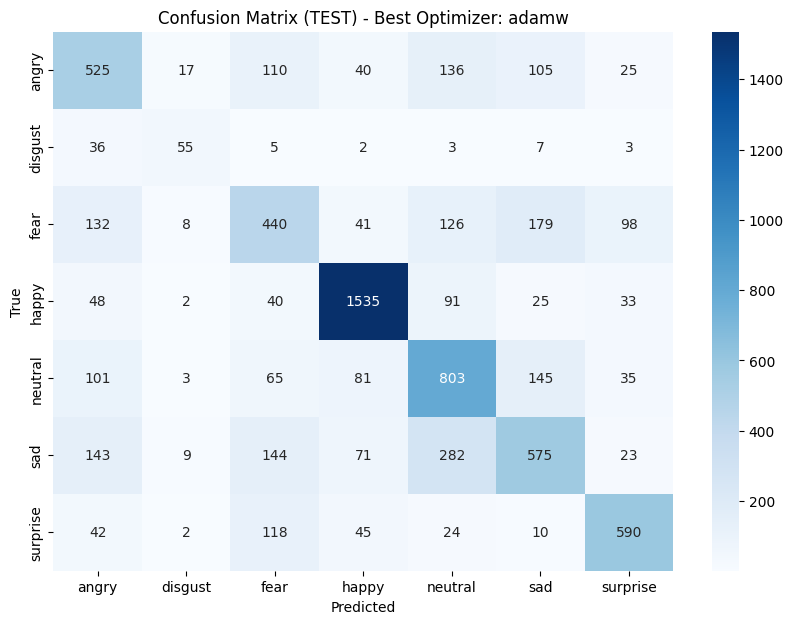

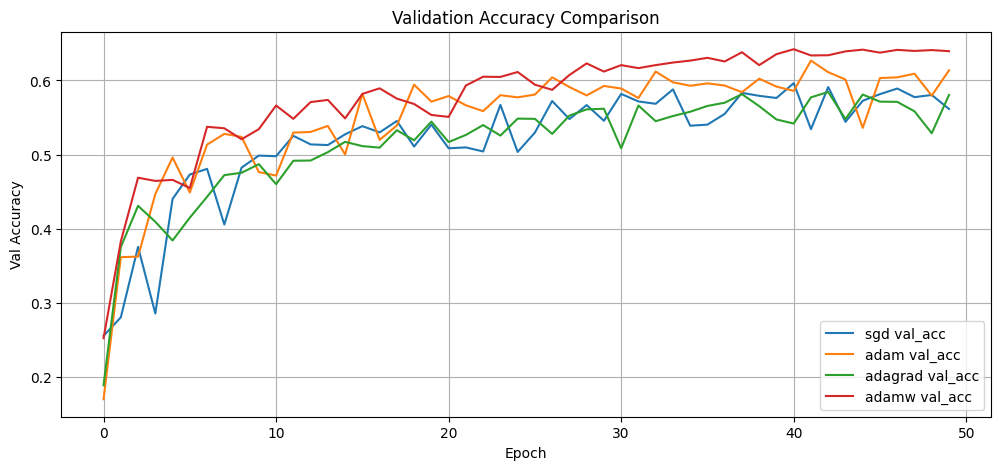

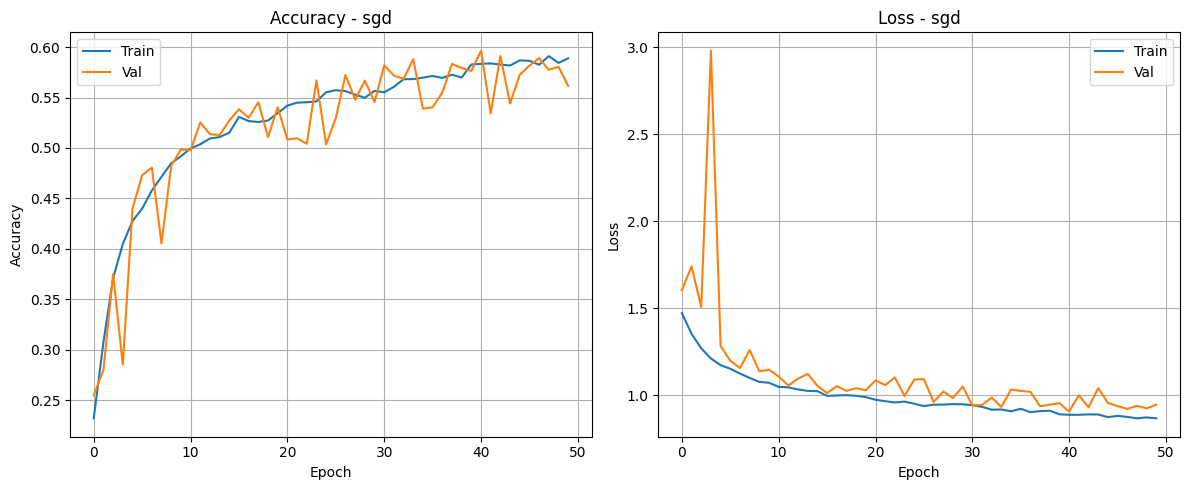

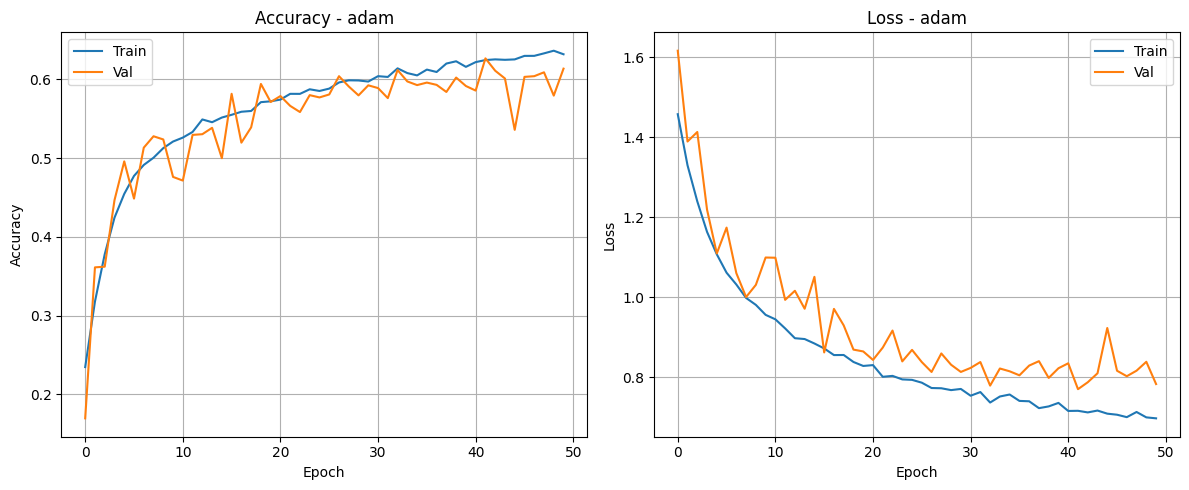

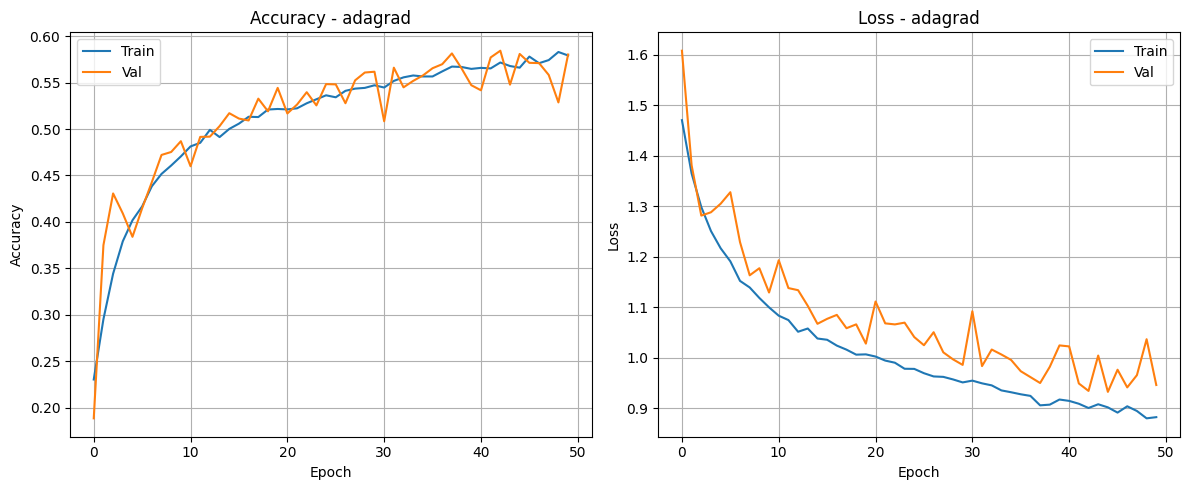

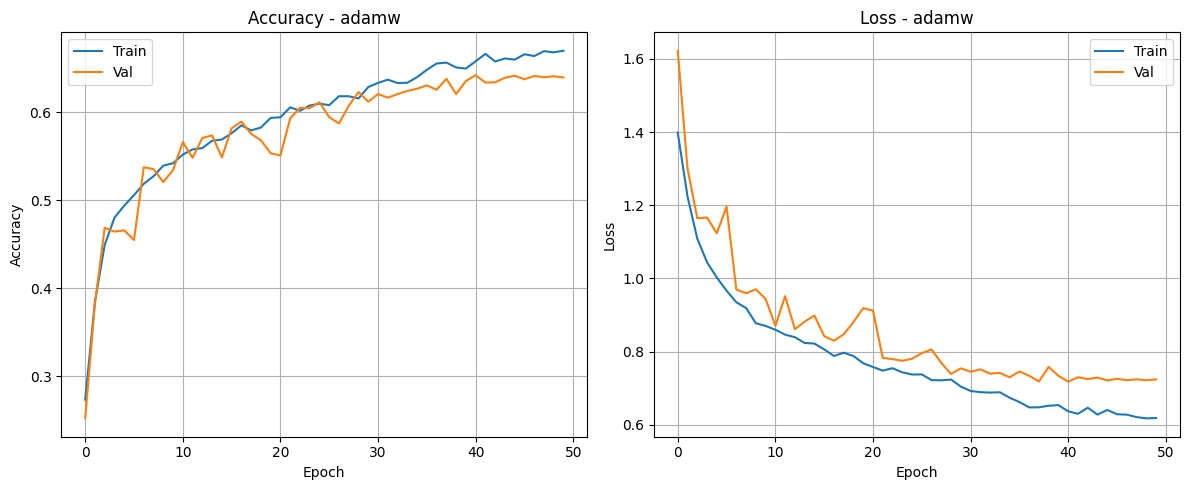


Saved deployable model to: /content/sample_data/action_model.keras
Saved labels mapping to: /content/sample_data/labels.json
Labels: {'0': 'angry', '1': 'disgust', '2': 'fear', '3': 'happy', '4': 'neutral', '5': 'sad', '6': 'surprise'}

Done.
Best checkpoint: best_adamw.h5
Saved deployable model: /content/sample_data/action_model.keras
Saved labels file: /content/sample_data/labels.json


In [ ]:
"""
FER-2013 Emotion Recognition
Dlib 68-Landmark Face Alignment + Mini-Xception CNN

Goal:
- Increase overall accuracy
- Improve fear recall WITHOUT destroying other classes
- Do NOT print fear recall or checkpoint on it

Edits in THIS version (as requested):
1) Cap class_weights (recommended) to help tiny classes like disgust with focal+mixup
2) Add AdamW as a 4th optimizer in the optimizer comparison
3) Save deployable model + labels.json after best optimizer is chosen
4) Keep everything else the same (pipeline/model/plots/table/eval)
"""

# ===========================================
# 1. IMPORTS
# ===========================================
import os
import math
import json
import urllib.request
import subprocess
import numpy as np
import cv2
import dlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, SeparableConv2D, BatchNormalization, ReLU, Add,
    GlobalAveragePooling2D, Dropout, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ===========================================
# 2. PATHS & SETTINGS
# ===========================================
train_dir = "/content/datasets/train"
test_dir  = "/content/datasets/test"

img_size = (48, 48)
num_classes = 7
batch_size = 64
epochs = 50
val_size = 0.12

label_smoothing = 0.05
weight_decay_l2 = 1e-4

# Your chosen values
MIXUP_ALPHA = 0.25
FOCAL_GAMMA = 1.7

# Class-weight cap (requested)
CLASS_WEIGHT_CAP = 2.5

# Deploy artifacts (requested)
DEPLOY_MODEL_PATH = "/content/sample_data/action_model.keras"
LABELS_PATH = "/content/sample_data/labels.json"

# ===========================================
# 3. CHECK CLASSES
# ===========================================
if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"train_dir not found: {train_dir}")
if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"test_dir not found: {test_dir}")

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", classes)
if len(classes) != num_classes:
    print(f"WARNING: num_classes={num_classes}, but found {len(classes)} folders.")

# ===========================================
# 4. DLIB SETUP (download shape predictor if missing)
# ===========================================
PRED_PATH = "shape_predictor_68_face_landmarks.dat"
PRED_BZ2  = "shape_predictor_68_face_landmarks.dat.bz2"
PRED_URL  = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"

def ensure_dlib_predictor():
    if os.path.exists(PRED_PATH):
        return
    print("Downloading Dlib shape predictor...")
    if not os.path.exists(PRED_BZ2):
        urllib.request.urlretrieve(PRED_URL, PRED_BZ2)
    print("Decompressing predictor (bz2)...")
    try:
        subprocess.run(["bzip2", "-dk", PRED_BZ2], check=True)
    except Exception as e:
        raise RuntimeError("Failed to decompress .bz2. Install bzip2 or decompress manually.") from e

ensure_dlib_predictor()

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PRED_PATH)

# ===========================================
# 5. PREPROCESSING: ALIGNMENT + CLAHE + STANDARDIZATION
# ===========================================
def preprocess_gray(gray48: np.ndarray) -> np.ndarray:
    """CLAHE + per-image standardization."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    g = clahe.apply(gray48)
    g = g.astype(np.float32)
    mean, std = float(g.mean()), float(g.std())
    g = (g - mean) / (std + 1e-6)
    return g

def align_face_dlib(img, output_size=(48,48), expand_ratio=0.30):
    """
    Face alignment using:
      - Dlib HOG detector
      - 68 landmarks
      - Eye-alignment rotation + expanded crop
    Returns: float32 (48,48) after preprocess_gray
    """
    if img is None:
        return np.zeros(output_size, np.float32)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rects = detector(gray, 1)

    if len(rects) == 0:
        g = cv2.resize(gray, output_size)
        return preprocess_gray(g)

    # choose the largest face (fixes rects[0] issue)
    rect = max(rects, key=lambda r: r.width() * r.height())

    shape = predictor(gray, rect)
    shape_np = np.array([[p.x, p.y] for p in shape.parts()], dtype=np.int32)

    left_eye  = shape_np[36:42].mean(axis=0).astype(np.int32)
    right_eye = shape_np[42:48].mean(axis=0).astype(np.int32)

    dy = int(right_eye[1] - left_eye[1])
    dx = int(right_eye[0] - left_eye[0])
    angle = float(np.degrees(np.arctan2(dy, dx)))

    eye_center = tuple(((left_eye + right_eye) // 2).tolist())
    rot_mat = cv2.getRotationMatrix2D(eye_center, angle, 1.0)
    rotated = cv2.warpAffine(
        gray, rot_mat, (gray.shape[1], gray.shape[0]),
        flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE
    )

    x, y, w, h = rect.left(), rect.top(), rect.width(), rect.height()
    x = max(0, int(x - w * expand_ratio))
    y = max(0, int(y - h * expand_ratio))
    w = int(w * (1 + 2 * expand_ratio))
    h = int(h * (1 + 2 * expand_ratio))

    x2 = min(rotated.shape[1], x + w)
    y2 = min(rotated.shape[0], y + h)

    crop = rotated[y:y2, x:x2]
    if crop.size == 0:
        g = cv2.resize(gray, output_size)
        return preprocess_gray(g)

    aligned = cv2.resize(crop, output_size)
    return preprocess_gray(aligned)

# ===========================================
# 6. LOAD DATASET
# ===========================================
def load_dataset(folder):
    X, y = [], []
    class_map = {cls: i for i, cls in enumerate(classes)}

    for cls in classes:
        folder_cls = os.path.join(folder, cls)
        if not os.path.isdir(folder_cls):
            continue

        for file in os.listdir(folder_cls):
            img_path = os.path.join(folder_cls, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            aligned = align_face_dlib(img, output_size=img_size)
            X.append(aligned)
            y.append(class_map[cls])

    X = np.array(X, dtype=np.float32).reshape(-1, 48, 48, 1)
    y = tf.keras.utils.to_categorical(y, num_classes)
    print(f"Loaded {X.shape[0]} images from {folder}")
    return X, y

print("\nLoading full training set...")
X_all, y_all = load_dataset(train_dir)

print("Loading test set (kept untouched)...")
X_test, y_test = load_dataset(test_dir)

# Train/Val split (stratified)
y_all_labels = np.argmax(y_all, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=val_size,
    random_state=42,
    stratify=y_all_labels
)
print(f"\nSplit: train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

# Class weights
y_train_labels = np.argmax(y_train, axis=1)
cw = compute_class_weight(class_weight="balanced", classes=np.arange(num_classes), y=y_train_labels)
class_weights = {i: float(w) for i, w in enumerate(cw)}
print("Class weights (raw):", class_weights)

# Requested edit: cap class weights
class_weights = {k: float(min(v, CLASS_WEIGHT_CAP)) for k, v in class_weights.items()}
print(f"Class weights (CAPPED at {CLASS_WEIGHT_CAP}):", class_weights)

# ===========================================
# 7. DATA AUGMENTATION
# ===========================================
datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.12,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15)
)
datagen.fit(X_train)

# ===========================================
# 8. MIXUP WRAPPER
# ===========================================
def mixup_batch(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y
    lam = np.random.beta(alpha, alpha)
    idx = np.random.permutation(x.shape[0])
    x2, y2 = x[idx], y[idx]
    return lam * x + (1 - lam) * x2, lam * y + (1 - lam) * y2

class MixupGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_gen, alpha=0.2):
        self.base_gen = base_gen
        self.alpha = alpha
    def __len__(self):
        return len(self.base_gen)
    def __getitem__(self, i):
        x, y = self.base_gen[i]
        return mixup_batch(x, y, self.alpha)

# ===========================================
# 9. MINI-XCEPTION
# ===========================================
def mini_xception(input_shape=(48,48,1), n_classes=7, wd=1e-4):
    inp = Input(input_shape)

    x = Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(wd))(inp)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(64, (3,3), strides=2, padding='same', kernel_regularizer=l2(wd))(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    def res_block(x, filters):
        res = Conv2D(filters, (1,1), strides=2, padding='same', kernel_regularizer=l2(wd))(x)

        y = SeparableConv2D(filters, (3,3), padding='same',
                            depthwise_regularizer=l2(wd), pointwise_regularizer=l2(wd))(x)
        y = BatchNormalization()(y)
        y = ReLU()(y)

        y = SeparableConv2D(filters, (3,3), strides=2, padding='same',
                            depthwise_regularizer=l2(wd), pointwise_regularizer=l2(wd))(y)
        y = BatchNormalization()(y)

        out = Add()([res, y])
        out = ReLU()(out)
        return out

    x = res_block(x, 128)
    x = res_block(x, 256)
    x = res_block(x, 512)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    out = Dense(n_classes, activation="softmax", kernel_regularizer=l2(wd))(x)
    return Model(inp, out)

# ===========================================
# 10. LOSS: Mild Focal CE with label smoothing
# ===========================================
def focal_categorical_loss(gamma=1.7, label_smoothing=0.0):
    ce = tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing, reduction="none")
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        base = ce(y_true, y_pred)  # per-sample
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)  # prob of true class
        focal = tf.pow(1.0 - pt, gamma)
        return tf.reduce_mean(focal * base)
    return loss

loss_fn = focal_categorical_loss(gamma=FOCAL_GAMMA, label_smoothing=label_smoothing)

# ===========================================
# 11. OPTIMIZERS TO COMPARE (added AdamW)
# ===========================================
def make_optimizer(name: str, steps_per_epoch: int = None, epochs: int = None):
    name = name.lower().strip()

    if name == "sgd":
        return tf.keras.optimizers.SGD(learning_rate=0.03, momentum=0.0, nesterov=False)

    if name == "adam":
        return tf.keras.optimizers.Adam(learning_rate=3e-4)

    if name == "adagrad":
        return tf.keras.optimizers.Adagrad(learning_rate=0.01)

    if name == "adamw":
        if steps_per_epoch is None or epochs is None:
            raise ValueError("adamw requires steps_per_epoch and epochs for cosine decay schedule.")
        total_steps = steps_per_epoch * epochs
        lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=8e-4,
            decay_steps=total_steps,
            alpha=1e-2
        )
        return tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4)

    raise ValueError(f"Unknown optimizer: {name}")

# ===========================================
# 12. TRAIN ONE RUN (per optimizer)
# ===========================================
def train_with_optimizer(opt_name: str, steps_per_epoch: int):
    tf.keras.backend.clear_session()

    model = mini_xception(input_shape=(48,48,1), n_classes=num_classes, wd=weight_decay_l2)
    optimizer = make_optimizer(opt_name, steps_per_epoch=steps_per_epoch, epochs=epochs)

    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

    ckpt_path = f"best_{opt_name}.h5"
    callbacks = [
        ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_accuracy", mode="max", verbose=1),
        EarlyStopping(monitor="val_accuracy", mode="max", patience=10, restore_best_weights=True, verbose=1),
    ]

    base_gen = datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True)
    train_gen = MixupGenerator(base_gen, alpha=MIXUP_ALPHA)

    print(f"\n==============================")
    print(f"Training with optimizer: {opt_name}")
    print(f"==============================")

    history = model.fit(
        train_gen,
        validation_data=(X_val, y_val),
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )

    best_val_acc = float(np.max(history.history["val_accuracy"]))
    best_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)

    return model, history, best_val_acc, best_epoch, ckpt_path

# ===========================================
# 13. RUN COMPARISON
# ===========================================
steps_per_epoch = math.ceil(len(X_train) / batch_size)

optimizers_to_test = ["sgd", "adam", "adagrad", "adamw"]
results = []
histories = {}

for opt in optimizers_to_test:
    model, history, best_val_acc, best_epoch, ckpt_path = train_with_optimizer(opt, steps_per_epoch=steps_per_epoch)
    results.append((opt, best_val_acc, best_epoch, ckpt_path))
    histories[opt] = history

# Print comparison table
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print("\n\n=== Optimizer Comparison (by best Val Accuracy) ===")
print(f"{'Optimizer':<10} | {'Best Val Acc':<12} | {'Best Epoch':<10} | {'Checkpoint'}")
print("-"*70)
for opt, acc, ep, ck in results_sorted:
    print(f"{opt:<10} | {acc:<12.4f} | {ep:<10d} | {ck}")

best_opt, best_acc, best_ep, best_ckpt = results_sorted[0]
print(f"\nBEST OPTIMIZER: {best_opt}  (best val acc={best_acc:.4f} at epoch {best_ep})")
print(f"Best checkpoint saved at: {best_ckpt}")

# Load best weights into a fresh model (safer)
best_model = mini_xception(input_shape=(48,48,1), n_classes=num_classes, wd=weight_decay_l2)
best_model.compile(optimizer=make_optimizer(best_opt, steps_per_epoch=steps_per_epoch, epochs=epochs),
                   loss=loss_fn, metrics=["accuracy"])
best_model.load_weights(best_ckpt)

# ===========================================
# 14. EVALUATE ON TEST (HONEST) USING BEST OPT
# ===========================================
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTEST accuracy (best optimizer={best_opt}): {test_acc:.4f}")

y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report (TEST):\n")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (TEST) - Best Optimizer: {best_opt}")
plt.show()

# ===========================================
# 15. PLOT 1: Validation Accuracy Comparison
# ===========================================
plt.figure(figsize=(12,5))
for opt in optimizers_to_test:
    plt.plot(histories[opt].history["val_accuracy"], label=f"{opt} val_acc")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ===========================================
# 16. PLOT 2: For each optimizer -> Accuracy + Loss (train/val)
# ===========================================
for opt in optimizers_to_test:
    h = histories[opt].history

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(h["accuracy"], label="Train")
    plt.plot(h["val_accuracy"], label="Val")
    plt.title(f"Accuracy - {opt}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(h["loss"], label="Train")
    plt.plot(h["val_loss"], label="Val")
    plt.title(f"Loss - {opt}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ===========================================
# 17. SAVE FINAL BEST MODEL + labels.json (requested)
# ===========================================
best_model.save(DEPLOY_MODEL_PATH)
print(f"\nSaved deployable model to: {DEPLOY_MODEL_PATH}")

labels = {str(i): cls for i, cls in enumerate(classes)}
with open(LABELS_PATH, "w") as f:
    json.dump(labels, f, indent=2)
print(f"Saved labels mapping to: {LABELS_PATH}")
print("Labels:", labels)

print("\nDone.")
print(f"Best checkpoint: {best_ckpt}")
print(f"Saved deployable model: {DEPLOY_MODEL_PATH}")
print(f"Saved labels file: {LABELS_PATH}")